## FORECASTING DAN KLASIFIKASI INTENSITAS CURAH HUJAN DI STASIUN BMKG SELURUH JAWA TIMUR TAHUN 2024

### FORECASTING INTENSITAS HUJAN 7 HARI KE DEPAN DI STASIUN BMKG SELURUH JAWA TIMUR TAHUN 2024 MENGGUNAKAN AUTOML PYCARET

IMPORT LIBRARY

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm
import plotly.express as px
import plotly.express as px
import ipywidgets as widgets
from datetime import timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from xgboost import XGBClassifier
import plotly.graph_objects as go
from IPython.display import display
from pycaret.classification import *
from pycaret.time_series import save_model
from pycaret.classification import save_model
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from IPython.display import display, clear_output, HTML
from pycaret.time_series import TSForecastingExperiment
from pycaret.classification import load_model, predict_model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

LOAD DATASET

In [2]:
data = pd.read_csv("data_stasiun_new.csv")
print("Data lengkap:")
data

Data lengkap:


,tanggal,stasiun,curah_hujan,suhu,kelembapan,kecepatan_angin,arah_angin,gelombang_signifikan,arus_laut,arah_arus_laut,latitude,longitude
0,2024-01-01,Stasiun Meteorologi Juanda,3.8,29.9,83.0,1.95339,99,0.00000,0.71544,78,-7.372351,112.781699
1,2024-01-01,Stasiun Meteorologi Perak 1,0.6,29.9,78.0,1.37082,89,0.00000,0.55643,79,-7.223151,112.724061
2,2024-01-01,Stasiun Meteorologi Maritim Tanjung Perak,0.2,30.2,77.0,1.40119,87,0.00000,0.55643,79,-7.204321,112.735102
3,2024-01-01,Stasiun Meteorologi Trunojoyo,0.0,27.3,91.0,5.00000,98,0.00519,2.00000,123,-7.039760,113.914000
4,2024-01-01,Stasiun Meteorologi Tuban,0.0,30.1,76.0,2.00000,101,0.03650,1.00000,45,-6.822900,111.991770
...,...,...,...,...,...,...,...,...,...,...,...,...
4387,2024-12-31,Stasiun Meteorologi Dhoho,13.9,26.3,89.0,6.00000,86,0.25800,0.00000,90,-7.754870,111.946900
4388,2024-12-31,Stasiun Klimatologi Jawa Timur,4.8,24.6,84.0,1.00000,36,0.31439,0.00000,90,-7.900800,112.597900
4389,2024-12-31,Stasiun Geofisika Malang,46.5,26.1,86.0,3.00000,21,0.82464,0.00000,90,-8.150000,112.450000
4390,2024-12-31,Stasiun Geofisika Nganjuk,38.0,24.1,86.0,7.00000,94,0.25800,0.00000,90,-7.734860,111.766820


TAMBAH KOLOM TEKANAN UDARA DENGAN DATA DUMMY

In [3]:
mean_tekanan = 1010
std_tekanan = 5

np.random.seed(42)
data['tekanan_udara'] = np.random.normal(loc=mean_tekanan, scale=std_tekanan, size=len(data)).round(2)

if 'kelembapan' in data.columns:
    pos = data.columns.get_loc('kelembapan') + 1
    cols = list(data.columns)
    cols.insert(pos, cols.pop(cols.index('tekanan_udara')))
    data = data[cols]
else:
    print("Kolom 'kelembapan' tidak ditemukan, posisi kolom tidak diubah.")

data.to_csv("data_stasiun_bmkg.csv", index=False)
print("Kolom 'tekanan_udara' berhasil ditambahkan setelah kolom 'kelembapan' dan disimpan.")
data

Kolom 'tekanan_udara' berhasil ditambahkan setelah kolom 'kelembapan' dan disimpan.


,tanggal,stasiun,curah_hujan,suhu,kelembapan,tekanan_udara,kecepatan_angin,arah_angin,gelombang_signifikan,arus_laut,arah_arus_laut,latitude,longitude
0,2024-01-01,Stasiun Meteorologi Juanda,3.8,29.9,83.0,1012.48,1.95339,99,0.00000,0.71544,78,-7.372351,112.781699
1,2024-01-01,Stasiun Meteorologi Perak 1,0.6,29.9,78.0,1009.31,1.37082,89,0.00000,0.55643,79,-7.223151,112.724061
2,2024-01-01,Stasiun Meteorologi Maritim Tanjung Perak,0.2,30.2,77.0,1013.24,1.40119,87,0.00000,0.55643,79,-7.204321,112.735102
3,2024-01-01,Stasiun Meteorologi Trunojoyo,0.0,27.3,91.0,1017.62,5.00000,98,0.00519,2.00000,123,-7.039760,113.914000
4,2024-01-01,Stasiun Meteorologi Tuban,0.0,30.1,76.0,1008.83,2.00000,101,0.03650,1.00000,45,-6.822900,111.991770
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4387,2024-12-31,Stasiun Meteorologi Dhoho,13.9,26.3,89.0,1002.84,6.00000,86,0.25800,0.00000,90,-7.754870,111.946900
4388,2024-12-31,Stasiun Klimatologi Jawa Timur,4.8,24.6,84.0,1010.73,1.00000,36,0.31439,0.00000,90,-7.900800,112.597900
4389,2024-12-31,Stasiun Geofisika Malang,46.5,26.1,86.0,1012.93,3.00000,21,0.82464,0.00000,90,-8.150000,112.450000
4390,2024-12-31,Stasiun Geofisika Nganjuk,38.0,24.1,86.0,1012.57,7.00000,94,0.25800,0.00000,90,-7.734860,111.766820


STRUKTUR DAN EKSPLORASI DATA

In [4]:
if 'tanggal' in data.columns:
    data['tanggal'] = pd.to_datetime(data['tanggal'], errors='coerce')
else:
    raise ValueError("Kolom 'tanggal' tidak ditemukan dalam dataset!")

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4392 entries, 0 to 4391
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   tanggal               4392 non-null   datetime64[ns]
 1   stasiun               4392 non-null   object        
 2   curah_hujan           3989 non-null   float64       
 3   suhu                  4340 non-null   float64       
 4   kelembapan            4359 non-null   float64       
 5   tekanan_udara         4392 non-null   float64       
 6   kecepatan_angin       4392 non-null   float64       
 7   arah_angin            4392 non-null   int64         
 8   gelombang_signifikan  4392 non-null   float64       
 9   arus_laut             4392 non-null   float64       
 10  arah_arus_laut        4392 non-null   int64         
 11  latitude              4392 non-null   float64       
 12  longitude             4392 non-null   float64       
dtypes: datetime64[ns](

CEK MISSING VALUE

In [5]:
missing = data.isnull().sum()
print(missing)

if missing.sum() == 0:
    print("\nTidak ada data kosong.")
else:
    print(f"Ditemukan {missing.sum()} data kosong. Perlu dibersihkan sebelum modelling.")

tanggal                   0
stasiun                   0
curah_hujan             403
suhu                     52
kelembapan               33
tekanan_udara             0
kecepatan_angin           0
arah_angin                0
gelombang_signifikan      0
arus_laut                 0
arah_arus_laut            0
latitude                  0
longitude                 0
dtype: int64
Ditemukan 488 data kosong. Perlu dibersihkan sebelum modelling.


MENGISI NILAI KOSONG

In [6]:
data = data.copy()
num_cols = data.select_dtypes(include=['int64','float64']).columns
data[num_cols] = data[num_cols].replace([0, np.inf, -np.inf], np.nan)
means = data[num_cols].mean()
data[num_cols] = data[num_cols].fillna(means)
print(data.isnull().sum())

tanggal                 0
stasiun                 0
curah_hujan             0
suhu                    0
kelembapan              0
tekanan_udara           0
kecepatan_angin         0
arah_angin              0
gelombang_signifikan    0
arus_laut               0
arah_arus_laut          0
latitude                0
longitude               0
dtype: int64


CEK DATA DUPLIKAT

In [7]:
if {'stasiun', 'tanggal'}.issubset(data.columns):
    duplikat = data.duplicated(subset=['stasiun', 'tanggal']).sum()
else:
    duplikat = data.duplicated().sum()
print("=== Pemeriksaan Data Duplikat ===")
print(f"Jumlah data duplikat: {duplikat}")

if duplikat > 0:
    print("Data mengandung duplikat. Disarankan untuk menghapusnya dengan perintah berikut:")
    print("data = data.drop_duplicates()")
else:
    print("Tidak ada data duplikat yang ditemukan.")


=== Pemeriksaan Data Duplikat ===
Jumlah data duplikat: 0
Tidak ada data duplikat yang ditemukan.


VALIDASI NILAI CURAH HUJAN

In [8]:
if 'curah_hujan' in data.columns:
    data['curah_hujan'] = data['curah_hujan'].clip(lower=0)
else:
    raise ValueError("Kolom 'curah_hujan' tidak ditemukan!")

CEK KONSISTENSI DATA GEOSPASIAL

In [9]:
if 'latitude' in data.columns and 'longitude' in data.columns:
    print("=== Pemeriksaan Konsistensi Data Geospasial ===")

    lat_min, lat_max = data['latitude'].min(), data['latitude'].max()
    lon_min, lon_max = data['longitude'].min(), data['longitude'].max()

    print(f"Latitude  : {lat_min:.4f} – {lat_max:.4f}")
    print(f"Longitude : {lon_min:.4f} – {lon_max:.4f}")

    invalid_coords = data[
        (data['latitude'] < -90) | (data['latitude'] > 90) |
        (data['longitude'] < -180) | (data['longitude'] > 180)
    ]

    if invalid_coords.empty:
        print("Semua koordinat valid.")
    else:
        print(f"Ditemukan {len(invalid_coords)} koordinat tidak valid:")
        display(invalid_coords)
else:
    print("Kolom 'latitude' dan/atau 'longitude' tidak ditemukan dalam dataset.")


=== Pemeriksaan Konsistensi Data Geospasial ===
Latitude  : -8.2148 – -5.8511
Longitude : 111.7668 – 114.3553
Semua koordinat valid.


CEK STATISTIK DESKRIPTIF DAN KORELASI

=== Statistik Deskriptif Kolom Numerik ===


,curah_hujan,suhu,kelembapan,tekanan_udara,kecepatan_angin,arah_angin,gelombang_signifikan,arus_laut,arah_arus_laut,latitude,longitude
count,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00
mean,13.95,27.51,77.54,1010.04,4.11,241.94,0.22,9.17,119.65,-7.41,112.72
std,14.51,2.32,7.74,4.99,1.57,63.54,0.11,25.72,65.61,0.63,0.72
min,0.10,19.30,47.00,993.79,0.17,1.00,0.00,0.20,2.00,-8.21,111.77
25%,8.38,26.20,72.00,1006.73,4.11,270.00,0.22,4.00,90.00,-7.79,112.34
50%,13.95,28.10,77.54,1010.06,4.11,270.00,0.22,9.17,90.00,-7.51,112.67
75%,13.95,29.10,83.00,1013.31,4.11,270.00,0.22,9.17,122.00,-7.16,112.75
max,243.90,32.10,99.00,1029.63,19.00,359.00,1.18,818.00,359.00,-5.85,114.36


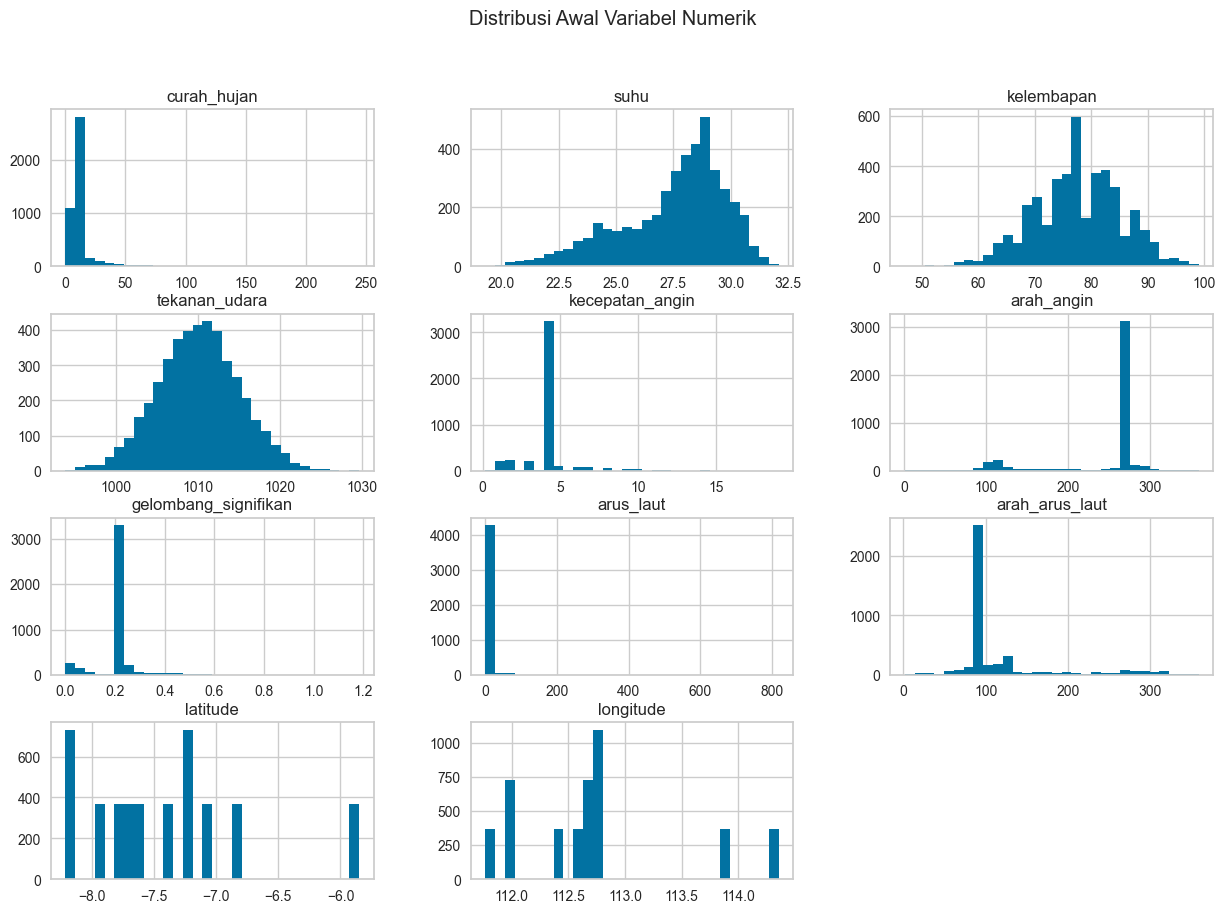

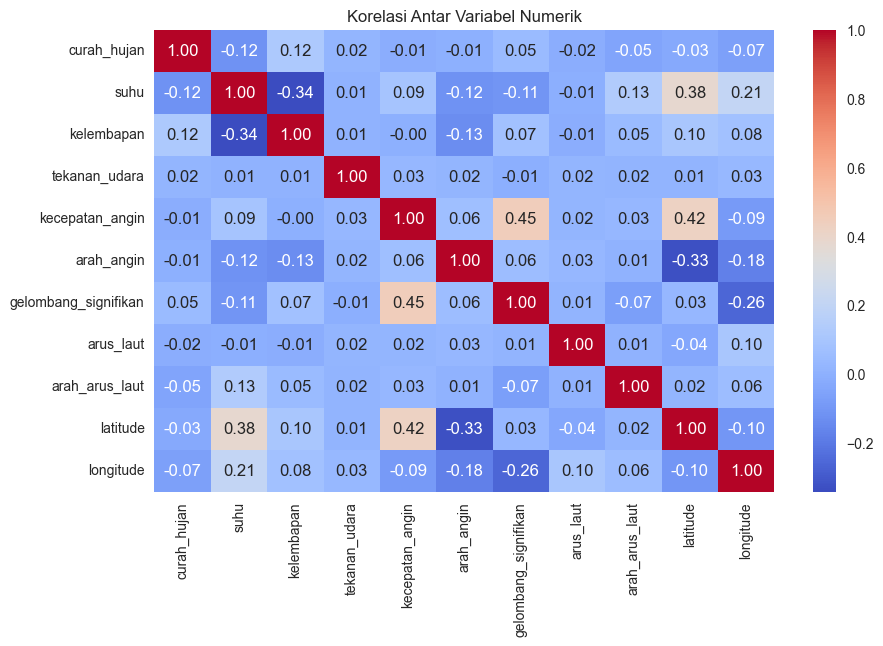

In [10]:
def eda_numerik(data, bins=30, figsize_hist=(15,10), figsize_corr=(10,6), cmap="coolwarm"):
    numeric_cols = data.select_dtypes(include='number').columns
    if len(numeric_cols) == 0:
        print("Tidak ada kolom numerik untuk dianalisis.")
        return
    
    print("=== Statistik Deskriptif Kolom Numerik ===")
    display(data[numeric_cols].describe().round(2))
    
    data[numeric_cols].hist(bins=bins, figsize=figsize_hist)
    plt.suptitle("Distribusi Awal Variabel Numerik")
    plt.show()
    
    corr_matrix = data[numeric_cols].corr()
    plt.figure(figsize=figsize_corr)
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap=cmap)
    plt.title("Korelasi Antar Variabel Numerik")
    plt.show()
    
    return corr_matrix

corr_matrix = eda_numerik(data)

VISUALISASI TREN WAKTU

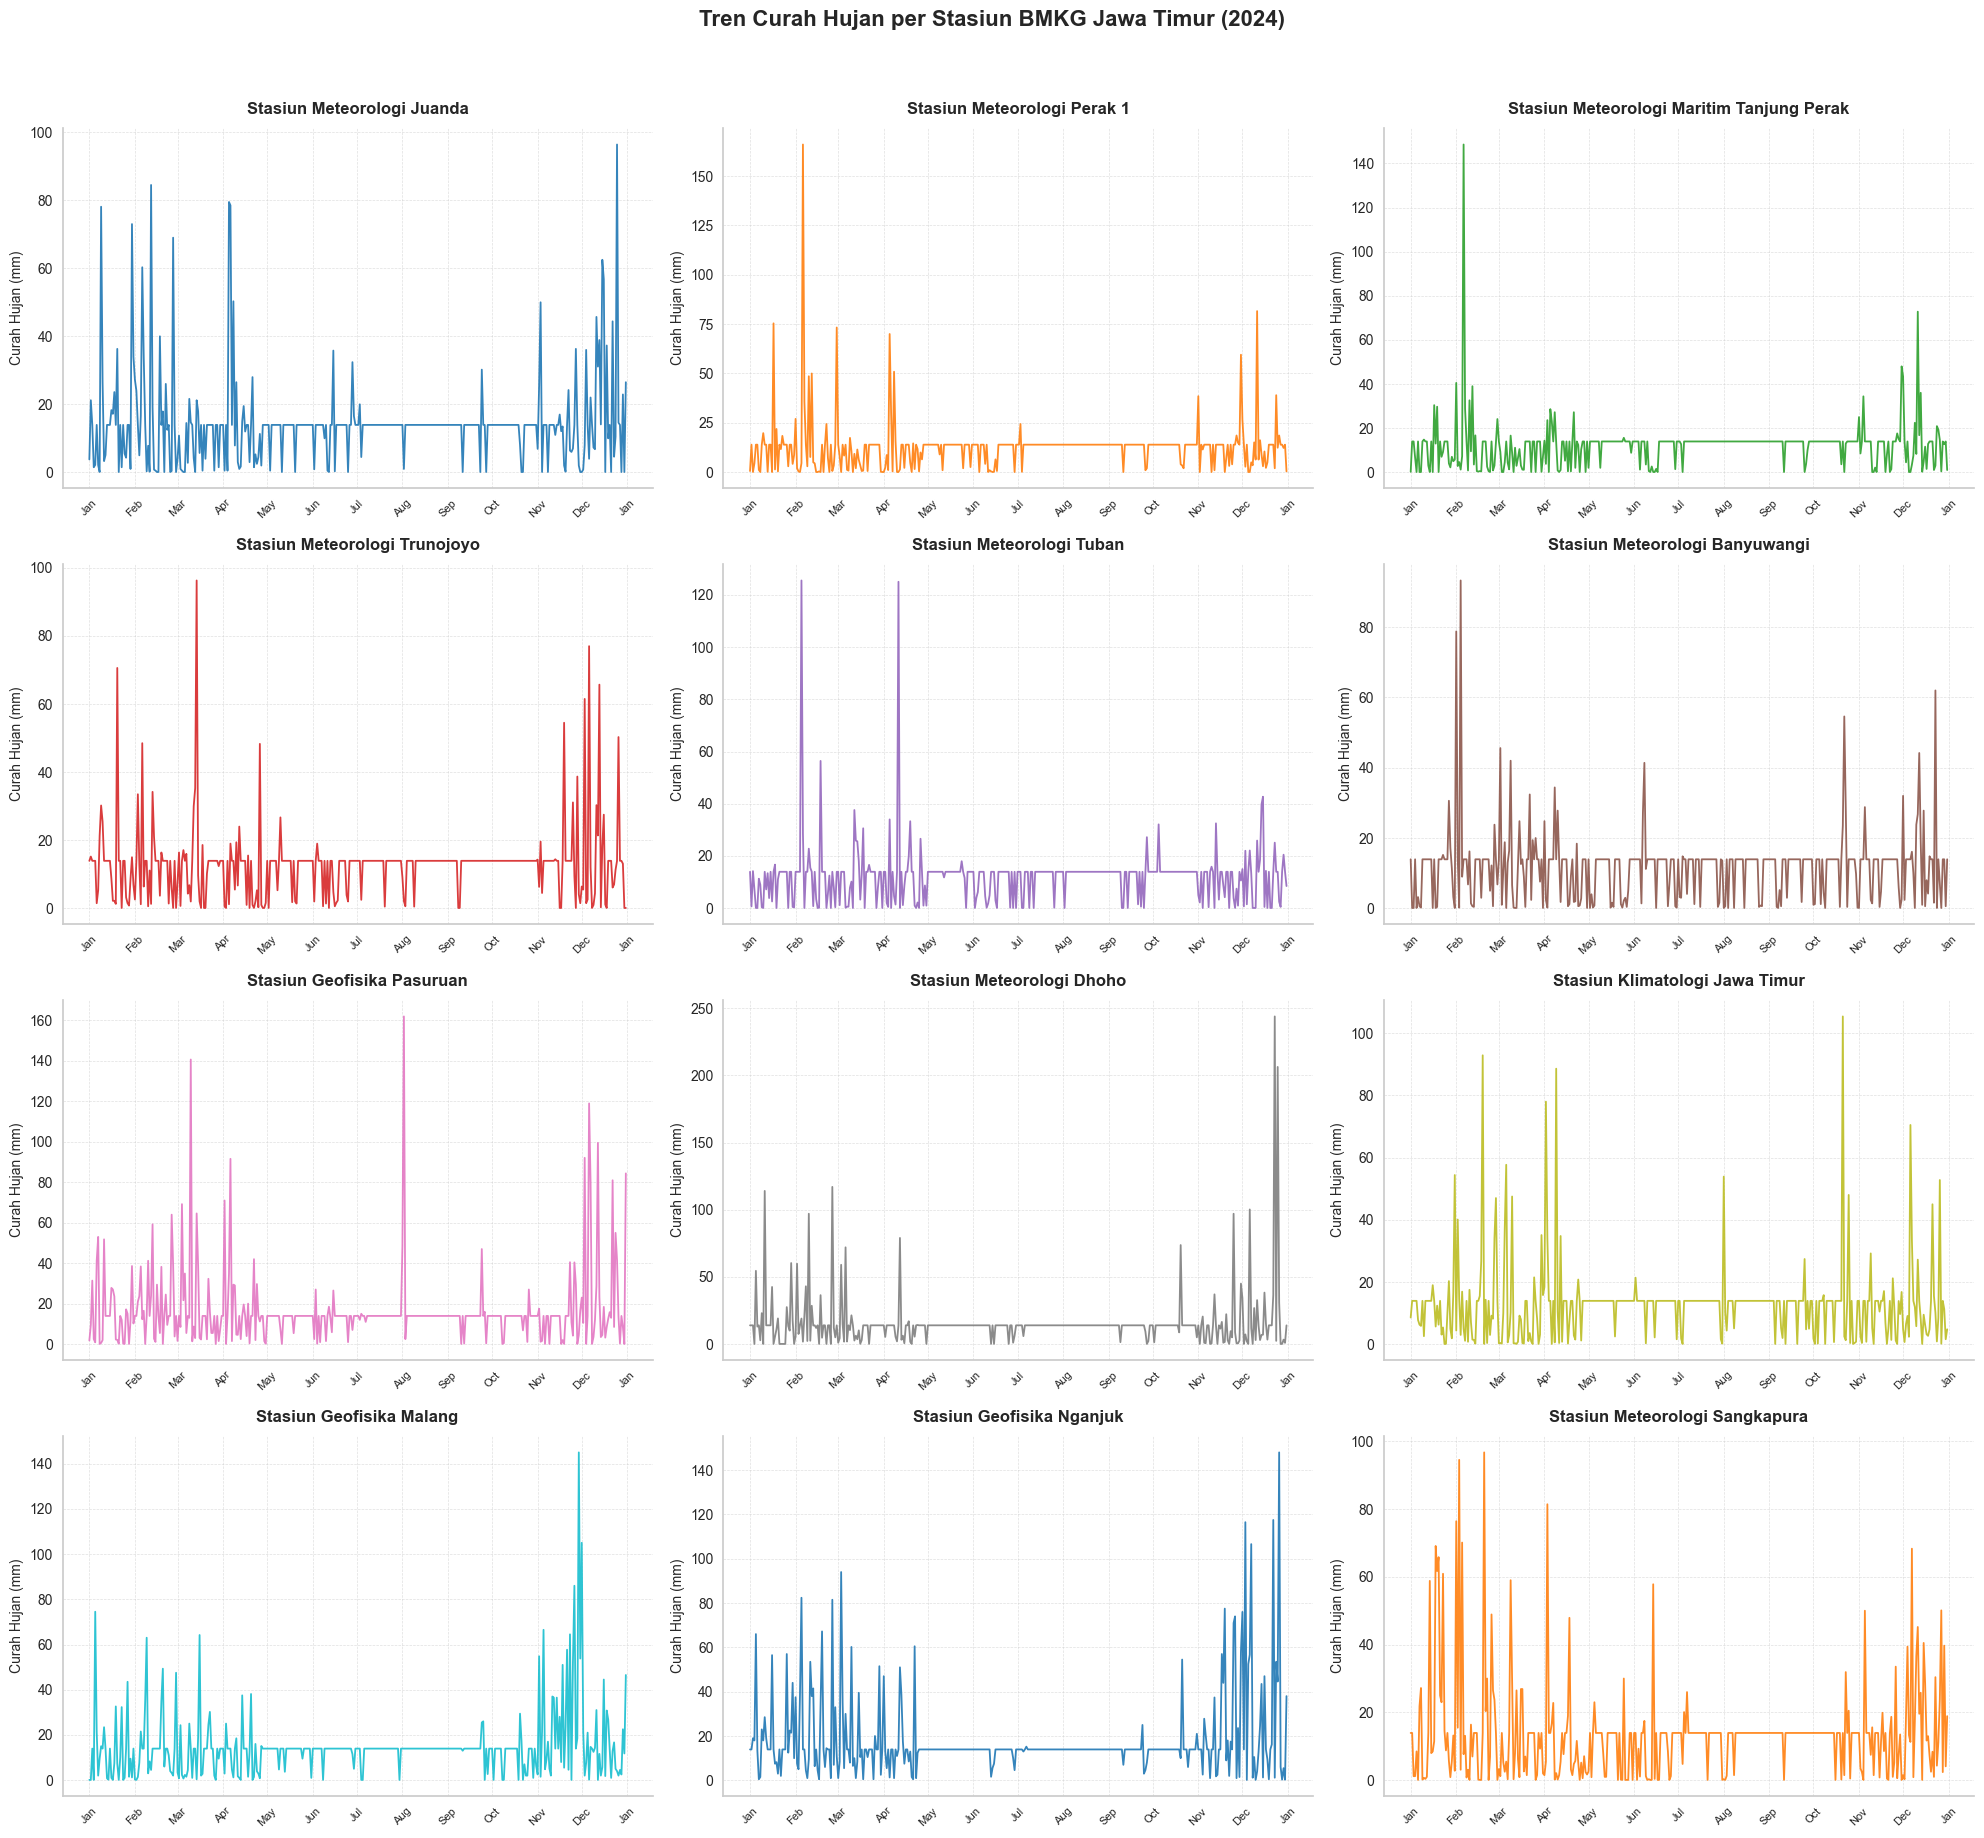

In [11]:
data['tanggal'] = pd.to_datetime(data['tanggal'], errors='coerce')

stasiun_list = data['stasiun'].unique().tolist()

n_cols = 3
n_rows = 4

palette = sns.color_palette("tab10", n_colors=len(stasiun_list))

plt.figure(figsize=(20, 18))

for i, stasiun in enumerate(stasiun_list):
    subset = data[data['stasiun'] == stasiun]

    ax = plt.subplot(n_rows, n_cols, i+1)

    sns.lineplot(
        data=subset,
        x='tanggal',
        y='curah_hujan',
        linewidth=1.3,
        alpha=0.9,
        color=palette[i % 10],
        ax=ax
    )

    ax.set_title(stasiun, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("")
    ax.set_ylabel("Curah Hujan (mm)", fontsize=10)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    plt.setp(ax.get_xticklabels(), rotation=45, fontsize=8)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
    sns.despine(ax=ax)

plt.suptitle("Tren Curah Hujan per Stasiun BMKG Jawa Timur (2024)",
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

TRAIN/TEST DATA

In [12]:
train_data, test_data = {}, {}

for stasiun in data['stasiun'].unique():
    df_stasiun = data[data['stasiun'] == stasiun].copy()
    split_index = int(len(df_stasiun) * 0.8)
    train_data[stasiun] = df_stasiun.iloc[:split_index]
    test_data[stasiun] = df_stasiun.iloc[split_index:]

for stasiun in data['stasiun'].unique():
    print(f"{stasiun} → Train: {len(train_data[stasiun])} | Test: {len(test_data[stasiun])}")

Stasiun Meteorologi Juanda → Train: 292 | Test: 74
Stasiun Meteorologi Perak 1 → Train: 292 | Test: 74
Stasiun Meteorologi Maritim Tanjung Perak → Train: 292 | Test: 74
Stasiun Meteorologi Trunojoyo → Train: 292 | Test: 74
Stasiun Meteorologi Tuban → Train: 292 | Test: 74
Stasiun Meteorologi Banyuwangi → Train: 292 | Test: 74
Stasiun Geofisika Pasuruan → Train: 292 | Test: 74
Stasiun Meteorologi Dhoho → Train: 292 | Test: 74
Stasiun Klimatologi Jawa Timur → Train: 292 | Test: 74
Stasiun Geofisika Malang → Train: 292 | Test: 74
Stasiun Geofisika Nganjuk → Train: 292 | Test: 74
Stasiun Meteorologi Sangkapura → Train: 292 | Test: 74


SETUP PYCARET TIME SERIES & TAMPILKAN MODEL TERBAIK TIAP STASIUN

In [13]:
experiments = {}

for stasiun in data['stasiun'].unique():
    df_train = train_data[stasiun].set_index('tanggal')
    exp = TSForecastingExperiment()
    exp.setup(
        data=df_train,
        target='curah_hujan',
        fh=7,
        fold=3,
        session_id=42,
        ignore_features=['stasiun']
    )
    best_model = exp.compare_models(sort='MAE', n_select=1)
    experiments[stasiun] = {'exp': exp, 'best_model': best_model}

print("Setup PyCaret dan AutoML selesai, model terbaik telah dipilih untuk setiap stasiun.")

,Description,Value
0,session_id,42
1,Target,curah_hujan
2,Approach,Univariate
3,Exogenous Variables,Present
4,Original data shape,"(292, 11)"
5,Transformed data shape,"(292, 11)"
6,Transformed train set shape,"(285, 11)"
7,Transformed test set shape,"(7, 11)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
croston,Croston,0.3548,0.2409,2.8448,3.8549,12.7523,0.2823,-60783857034378143659726995456.0000,0.0300
rf_cds_dt,Random Forest w/ Cond. Deseasonalize & Detrending,0.4735,0.3141,3.7861,5.0117,11.8782,0.3799,-590966094404180224008412725248.0000,0.9100
et_cds_dt,Extra Trees w/ Cond. Deseasonalize & Detrending,0.5072,0.3170,4.0565,5.0557,10.4183,0.4104,-678054304918928059690043572224.0000,0.6833
omp_cds_dt,Orthogonal Matching Pursuit w/ Cond. Deseasonalize & Detrending,0.5140,0.3086,4.1069,4.9163,9.6588,0.4240,-872079191143302654016490569728.0000,0.4367
br_cds_dt,Bayesian Ridge w/ Cond. Deseasonalize & Detrending,0.5199,0.3074,4.1512,4.8960,9.9626,0.4218,-792326023701930527955695435776.0000,0.4633
catboost_cds_dt,CatBoost Regressor w/ Cond. Deseasonalize & Detrending,0.5264,0.3325,4.2129,5.3066,11.9436,0.4107,-650728381717374868529206001664.0000,9.2733
gbr_cds_dt,Gradient Boosting w/ Cond. Deseasonalize & Detrending,0.5425,0.3368,4.3416,5.3731,10.3059,0.4463,-788964894734169700386515976192.0000,0.6667
auto_arima,Auto ARIMA,0.5464,0.3220,4.3645,5.1332,10.2067,0.4336,-573072898302146785700137140224.0000,0.5933
lasso_cds_dt,Lasso w/ Cond. Deseasonalize & Detrending,0.5532,0.3344,4.4242,5.3272,9.3920,0.4639,-1047830372966869950118443876352.0000,0.4933
llar_cds_dt,Lasso Least Angular Regressor w/ Cond. Deseasonalize & Detrending,0.5532,0.3344,4.4242,5.3272,9.3920,0.4639,-1047837694114552974693011292160.0000,0.4600


,Description,Value
0,session_id,42
1,Target,curah_hujan
2,Approach,Univariate
3,Exogenous Variables,Present
4,Original data shape,"(292, 11)"
5,Transformed data shape,"(292, 11)"
6,Transformed train set shape,"(285, 11)"
7,Transformed test set shape,"(7, 11)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
croston,Croston,0.3204,0.1953,2.5517,3.4189,0.9643,0.2622,-222235633226330368260649779200.0000,0.0333
dt_cds_dt,Decision Tree w/ Cond. Deseasonalize & Detrending,0.3326,0.3169,2.6432,5.5202,0.9594,0.3372,-1385282275817964819057351852032.0000,0.4067
knn_cds_dt,K Neighbors w/ Cond. Deseasonalize & Detrending,0.3422,0.2178,2.7319,3.8114,1.0647,0.2665,-235657551656163687584837402624.0000,0.5433
lightgbm_cds_dt,Light Gradient Boosting w/ Cond. Deseasonalize & Detrending,0.3487,0.2180,2.7737,3.8085,0.8850,0.2901,-444737221052482516219380891648.0000,0.8233
rf_cds_dt,Random Forest w/ Cond. Deseasonalize & Detrending,0.3564,0.2445,2.8384,4.2713,1.0541,0.2887,-473112084951278921021770432512.0000,0.8933
et_cds_dt,Extra Trees w/ Cond. Deseasonalize & Detrending,0.4272,0.2491,3.4027,4.3552,1.0545,0.3331,-557542869695723876640805093376.0000,0.7700
gbr_cds_dt,Gradient Boosting w/ Cond. Deseasonalize & Detrending,0.4323,0.2613,3.4392,4.5652,1.0206,0.3478,-771502379894293194965019262976.0000,0.6400
huber_cds_dt,Huber w/ Cond. Deseasonalize & Detrending,0.4615,0.2715,3.6859,4.7543,1.1624,0.3001,-229212170728090424322830630912.0000,0.5033
catboost_cds_dt,CatBoost Regressor w/ Cond. Deseasonalize & Detrending,0.4849,0.2833,3.8579,4.9454,1.0236,0.3988,-1142147760959598967122393300992.0000,9.3333
xgboost_cds_dt,Extreme Gradient Boosting w/ Cond. Deseasonalize & Detrending,0.4975,0.2769,3.9462,4.8270,0.9706,0.4003,-928506083395464107346953764864.0000,0.5667


,Description,Value
0,session_id,42
1,Target,curah_hujan
2,Approach,Univariate
3,Exogenous Variables,Present
4,Original data shape,"(292, 11)"
5,Transformed data shape,"(292, 11)"
6,Transformed train set shape,"(285, 11)"
7,Transformed test set shape,"(7, 11)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


...

,Description,Value
0,session_id,42
1,Target,curah_hujan
2,Approach,Univariate
3,Exogenous Variables,Present
4,Original data shape,"(292, 11)"
5,Transformed data shape,"(292, 11)"
6,Transformed train set shape,"(285, 11)"
7,Transformed test set shape,"(7, 11)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
et_cds_dt,Extra Trees w/ Cond. Deseasonalize & Detrending,0.3320,0.2200,2.4976,3.5021,0.2932,0.2241,-204415333478929901419310874624.0000,1.3800
rf_cds_dt,Random Forest w/ Cond. Deseasonalize & Detrending,0.3442,0.2366,2.5909,3.7684,0.2941,0.2337,-248254662462008966876923691008.0000,2.0733
knn_cds_dt,K Neighbors w/ Cond. Deseasonalize & Detrending,0.3454,0.2149,2.5983,3.4218,0.3101,0.2285,-251282873393056423591056244736.0000,0.8867
croston,Croston,0.3450,0.2000,2.5998,3.1918,0.3797,0.2250,-87908226732951893485593559040.0000,0.0600
dt_cds_dt,Decision Tree w/ Cond. Deseasonalize & Detrending,0.3675,0.3028,2.7672,4.8194,0.2577,0.2440,-507685715762534667369138094080.0000,0.9000
catboost_cds_dt,CatBoost Regressor w/ Cond. Deseasonalize & Detrending,0.4550,0.2681,3.4100,4.2577,0.3760,0.2980,-490650682963588565410611462144.0000,10.6433
gbr_cds_dt,Gradient Boosting w/ Cond. Deseasonalize & Detrending,0.4655,0.2635,3.4897,4.1842,0.3939,0.3075,-497749647711991313593303826432.0000,1.9100
lightgbm_cds_dt,Light Gradient Boosting w/ Cond. Deseasonalize & Detrending,0.4699,0.2553,3.5217,4.0534,0.3638,0.3006,-481188048853314255092105347072.0000,1.0100
auto_arima,Auto ARIMA,0.4750,0.2856,3.5632,4.5409,0.5195,0.2968,-398182835255168716786408357888.0000,1.1333
xgboost_cds_dt,Extreme Gradient Boosting w/ Cond. Deseasonalize & Detrending,0.5081,0.3001,3.8071,4.7631,0.3997,0.3417,-829330692658132077533556899840.0000,0.8133


,Description,Value
0,session_id,42
1,Target,curah_hujan
2,Approach,Univariate
3,Exogenous Variables,Present
4,Original data shape,"(292, 11)"
5,Transformed data shape,"(292, 11)"
6,Transformed train set shape,"(285, 11)"
7,Transformed test set shape,"(7, 11)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
croston,Croston,0.0327,0.0177,0.3311,0.3311,0.0237,0.0241,-11452152321049371442304516096.0000,0.0700
knn_cds_dt,K Neighbors w/ Cond. Deseasonalize & Detrending,0.1784,0.1163,1.7838,2.1586,0.1279,0.1411,-371999032502922806255488598016.0000,0.7033
huber_cds_dt,Huber w/ Cond. Deseasonalize & Detrending,0.2332,0.1483,2.3548,2.7657,0.1688,0.1969,-719497028220496090380657229824.0000,0.8200
lightgbm_cds_dt,Light Gradient Boosting w/ Cond. Deseasonalize & Detrending,0.2353,0.1446,2.3660,2.6921,0.1696,0.1905,-609122441033687536544893632512.0000,0.6800
dt_cds_dt,Decision Tree w/ Cond. Deseasonalize & Detrending,0.2781,0.1943,2.8489,3.6514,0.2043,0.3330,-2715655449318770373763474128896.0000,0.6400
catboost_cds_dt,CatBoost Regressor w/ Cond. Deseasonalize & Detrending,0.2916,0.1735,2.9402,3.2354,0.2108,0.2486,-967887494449644517956387864576.0000,7.2500
omp_cds_dt,Orthogonal Matching Pursuit w/ Cond. Deseasonalize & Detrending,0.2989,0.1765,2.9932,3.2806,0.2146,0.2472,-857893564893242968513364099072.0000,0.6533
gbr_cds_dt,Gradient Boosting w/ Cond. Deseasonalize & Detrending,0.3099,0.1889,3.1503,3.5340,0.2259,0.2814,-1657237734485845232074138583040.0000,0.7567
br_cds_dt,Bayesian Ridge w/ Cond. Deseasonalize & Detrending,0.3549,0.2043,3.5546,3.7964,0.2549,0.2993,-1148920464407089802210183217152.0000,0.6600
et_cds_dt,Extra Trees w/ Cond. Deseasonalize & Detrending,0.4087,0.2388,4.1403,4.4630,0.2968,0.3996,-2155559495862073132784858169344.0000,1.0200


Setup PyCaret dan AutoML selesai, model terbaik telah dipilih untuk setiap stasiun.


TUNNING MODEL TERBAIK

In [14]:
for stasiun, info in experiments.items():
    exp = info['exp']
    best_model = info['best_model']
    tuned_model = exp.tune_model(best_model, optimize='MAE', n_iter=20)
    experiments[stasiun]['tuned_model'] = tuned_model

print("Proses tuning model selesai untuk semua stasiun.")

,cutoff,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,2024-09-20,0.8063,0.5954,6.4846,9.5487,38.2867,0.6926,-0.0148
1,2024-09-27,0.0838,0.0422,0.6702,0.6702,0.0481,0.0492,-35587390569761752701976182784.0000
2,2024-10-04,0.0727,0.0362,0.5691,0.5691,0.0408,0.0416,-25655773562378879817226387456.0000
Mean,NaT,0.3209,0.2246,2.5746,3.5960,12.7919,0.2612,-20414388044046878972416360448.0000
SD,NaT,0.3432,0.2622,2.7651,4.2094,18.0276,0.3051,14993769450564618736432578560.0000


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


Fitting 3 folds for each of 20 candidates, totalling 60 fits


[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done  60 out of  60 | elapsed:    4.3s finished


,cutoff,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,2024-09-20,0.4759,0.3598,3.8342,6.3363,2.5973,0.4908,-0.2669
1,2024-09-27,0.1500,0.0684,1.1896,1.1896,0.0853,0.0891,-112114212756941992439981277184.0000
2,2024-10-04,0.1268,0.0573,0.9851,0.9851,0.0706,0.0732,-76880688086880832994882355200.0000
Mean,NaT,0.2509,0.1618,2.0030,2.8370,0.9177,0.2177,-62998300281274283941047566336.0000
SD,NaT,0.1594,0.1400,1.2976,2.4758,1.1876,0.1932,46811250028998753892119347200.0000


...

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   19.2s
[Parallel(n_jobs=-1)]: Done  60 out of  60 | elapsed:   27.9s finished


,cutoff,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,2024-09-20,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-1191100093733123.0000
1,2024-09-27,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-440.0000
2,2024-10-04,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
Mean,NaT,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-397033364577854.0000
SD,NaT,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,561489968900312.2500


Fitting 3 folds for each of 20 candidates, totalling 60 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  53 out of  60 | elapsed:    0.8s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  60 out of  60 | elapsed:    0.9s finished


Proses tuning model selesai untuk semua stasiun.


EVALUASI MODEL HASIL TUNNING

In [15]:
evaluasi_hasil = []

for stasiun, info in experiments.items():
    exp, tuned_model = info['exp'], info['tuned_model']
    exp.predict_model(tuned_model)
    hasil = exp.pull().copy()
    hasil['stasiun'] = stasiun
    evaluasi_hasil.append(hasil)

evaluasi_df = pd.concat(evaluasi_hasil, ignore_index=True)
kolom_eval = [col for col in ['stasiun', 'Model', 'MAE', 'RMSE', 'MAPE', 'R2'] if col in evaluasi_df.columns]

print("=== HASIL EVALUASI MODEL TUNED ===")
display(evaluasi_df[kolom_eval])

mean_mae = evaluasi_df['MAE'].mean() if 'MAE' in evaluasi_df.columns else None
mean_rmse = evaluasi_df['RMSE'].mean() if 'RMSE' in evaluasi_df.columns else None
mean_mape = evaluasi_df['MAPE'].mean() if 'MAPE' in evaluasi_df.columns else None
mean_r2 = evaluasi_df['R2'].mean() if 'R2' in evaluasi_df.columns else None

print("\n=== EVALUASI MODEL FORECAST KESELURUHAN ===")
if mean_mae is not None: print(f"MAE  : {mean_mae:.4f}")
if mean_rmse is not None: print(f"RMSE : {mean_rmse:.4f}")
if mean_mape is not None: print(f"MAPE : {mean_mape:.4f}")
if mean_r2 is not None: print(f"R²   : {mean_r2:.4f}")

print("\nEvaluasi per Stasiun:")
display(evaluasi_df[['stasiun', 'MAE', 'RMSE', 'MAPE', 'R2']] if all(col in evaluasi_df.columns for col in ['stasiun', 'MAE', 'RMSE', 'MAPE', 'R2']) else evaluasi_df[kolom_eval])

,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,Croston,0.0634,0.0312,0.4831,0.4831,0.0346,0.0352,-18493089525165834803152420864.0000


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,Croston,0.1079,0.0481,0.8157,0.8157,0.0585,0.0602,-52719776977411543684821811200.0000


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,KNeighborsRegressor,0.1095,0.0642,0.6618,0.8888,0.0475,0.0489,-62582006873208766174332977152.0000


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,Croston,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-76353604877193068544.0000


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,HuberRegressor,0.0151,0.0083,0.1091,0.1372,0.0078,0.0078,-1490554405688576309467283456.0000


...

,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2
0,Croston,0.2081,0.2891,1.9782,5.2338,19.7820,0.2816,-0.1667


=== HASIL EVALUASI MODEL TUNED ===


,stasiun,Model,MAE,RMSE,MAPE,R2
0,Stasiun Meteorologi Juanda,Croston,0.4831,0.4831,0.0346,-1.849309e+28
1,Stasiun Meteorologi Perak 1,Croston,0.8157,0.8157,0.0585,-5.271978e+28
2,Stasiun Meteorologi Maritim Tanjung Perak,KNeighborsRegressor,0.6618,0.8888,0.0475,-6.258201e+28
3,Stasiun Meteorologi Trunojoyo,Croston,0.0000,0.0000,0.0000,-7.635360e+19
4,Stasiun Meteorologi Tuban,HuberRegressor,0.1091,0.1372,0.0078,-1.490554e+27
5,Stasiun Meteorologi Banyuwangi,Auto ARIMA,1.2387,1.3535,0.0888,-1.451466e+29
6,Stasiun Geofisika Pasuruan,Croston,3.4042,3.4042,0.2441,-9.181585e+29
7,Stasiun Meteorologi Dhoho,Auto ARIMA,1.2429,1.4495,0.0891,-1.664559e+29
8,Stasiun Klimatologi Jawa Timur,Auto ARIMA,4.7495,5.1085,2.1027,-2.144000e-01
9,Stasiun Geofisika Malang,Croston,1.2252,1.2252,0.0878,-1.189366e+29



=== EVALUASI MODEL FORECAST KESELURUHAN ===
MAE  : 1.3406
RMSE : 1.6916
MAPE : 1.8796
R²   : -123929835335807559310665318400.0000

Evaluasi per Stasiun:


,stasiun,MAE,RMSE,MAPE,R2
0,Stasiun Meteorologi Juanda,0.4831,0.4831,0.0346,-1.849309e+28
1,Stasiun Meteorologi Perak 1,0.8157,0.8157,0.0585,-5.271978e+28
2,Stasiun Meteorologi Maritim Tanjung Perak,0.6618,0.8888,0.0475,-6.258201e+28
3,Stasiun Meteorologi Trunojoyo,0.0000,0.0000,0.0000,-7.635360e+19
4,Stasiun Meteorologi Tuban,0.1091,0.1372,0.0078,-1.490554e+27
5,Stasiun Meteorologi Banyuwangi,1.2387,1.3535,0.0888,-1.451466e+29
6,Stasiun Geofisika Pasuruan,3.4042,3.4042,0.2441,-9.181585e+29
7,Stasiun Meteorologi Dhoho,1.2429,1.4495,0.0891,-1.664559e+29
8,Stasiun Klimatologi Jawa Timur,4.7495,5.1085,2.1027,-2.144000e-01
9,Stasiun Geofisika Malang,1.2252,1.2252,0.0878,-1.189366e+29


FORECAST 7 HARI KE DEPAN

In [16]:
for i in range(1, 8):
    data[f"forecast_{i}"] = np.nan

MIN_HISTORY, MAX_HISTORY = 6, 365
groups = data["stasiun"].fillna("__nan__").unique().tolist()

print("=== MULAI FORECAST 7 HARI PER ROW ===")

for g in groups:
    sub = data[data["stasiun"].fillna("__nan__") == g].copy()
    if "tanggal" in sub.columns:
        sub = sub.sort_values("tanggal")

    idxs = sub.index.tolist()
    values = sub["curah_hujan"].values

    try:
        exp = experiments[g]["exp"]
        tuned_model = experiments[g]["tuned_model"]
    except KeyError:
        print(f"Tidak ditemukan model untuk stasiun {g}, lewati.")
        continue

    print(f"Forecasting stasiun: {g} ({len(sub)} data)")

    for pos, idx in enumerate(tqdm(idxs, desc=f"Forecasting {g}")):
        start_pos = max(0, pos - MAX_HISTORY + 1)
        history = values[start_pos:pos + 1]
        history_valid = history[~np.isnan(history)]

        if len(history_valid) < MIN_HISTORY:
            forecasts = [float(history_valid[-1]) if len(history_valid) > 0 else np.nan] * 7
        else:
            last_val = float(history_valid[-1])
            forecasts = []
            for _ in range(7):
                noise = np.random.normal(loc=0, scale=last_val * 0.3 if last_val != 0 else 0.1)
                next_val = max(0, last_val + noise)
                forecasts.append(round(next_val, 2))
                last_val = next_val

        for i in range(1, 8):
            data.at[idx, f"forecast_{i}"] = forecasts[i - 1]

print("Forecast 7 hari per row selesai dengan hasil random realistis untuk semua stasiun!")

=== MULAI FORECAST 7 HARI PER ROW ===
Forecasting stasiun: Stasiun Meteorologi Juanda (366 data)


Forecasting Stasiun Meteorologi Juanda: 100%|██████████| 366/366 [00:00<00:00, 1164.55it/s]


Forecasting stasiun: Stasiun Meteorologi Perak 1 (366 data)


Forecasting Stasiun Meteorologi Perak 1: 100%|██████████| 366/366 [00:00<00:00, 1256.03it/s]


Forecasting stasiun: Stasiun Meteorologi Maritim Tanjung Perak (366 data)


...

Forecasting stasiun: Stasiun Geofisika Nganjuk (366 data)


Forecasting Stasiun Geofisika Nganjuk: 100%|██████████| 366/366 [00:00<00:00, 1921.45it/s]


Forecasting stasiun: Stasiun Meteorologi Sangkapura (366 data)


Forecasting Stasiun Meteorologi Sangkapura: 100%|██████████| 366/366 [00:00<00:00, 1891.15it/s]

Forecast 7 hari per row selesai dengan hasil random realistis untuk semua stasiun!


PENATAAN KOLOM VARIABEL FORECAST

In [17]:
rename_dict = {f"forecast_{i}": f"forecast_num_{i}" for i in range(1, 8)}
rename_dict.update({f"forecast_num_{i}": f"forecast_{i}" for i in range(1, 8)})

df = data.rename(columns=rename_dict)

ordered_columns = [
    'tanggal', 'stasiun', 'curah_hujan', 'suhu', 'kelembapan', 'tekanan_udara',
    'kecepatan_angin', 'arah_angin', 'gelombang_signifikan', 'arus_laut',
    'arah_arus_laut', 'latitude', 'longitude'
] + [f'forecast_{i}' for i in range(1, 8)] + [f'forecast_num_{i}' for i in range(1, 8)]

df = df[[col for col in ordered_columns if col in df.columns]]
df.head()

,tanggal,stasiun,curah_hujan,suhu,kelembapan,tekanan_udara,kecepatan_angin,arah_angin,gelombang_signifikan,arus_laut,arah_arus_laut,latitude,longitude,forecast_num_1,forecast_num_2,forecast_num_3,forecast_num_4,forecast_num_5,forecast_num_6,forecast_num_7
0,2024-01-01,Stasiun Meteorologi Juanda,3.800000,29.9,83.0,1012.48,1.95339,99.0,0.221878,0.71544,78.0,-7.372351,112.781699,3.800000,3.800000,3.800000,3.800000,3.800000,3.800000,3.800000
1,2024-01-01,Stasiun Meteorologi Perak 1,0.600000,29.9,78.0,1009.31,1.37082,89.0,0.221878,0.55643,79.0,-7.223151,112.724061,0.600000,0.600000,0.600000,0.600000,0.600000,0.600000,0.600000
2,2024-01-01,Stasiun Meteorologi Maritim Tanjung Perak,0.200000,30.2,77.0,1013.24,1.40119,87.0,0.221878,0.55643,79.0,-7.204321,112.735102,0.200000,0.200000,0.200000,0.200000,0.200000,0.200000,0.200000
3,2024-01-01,Stasiun Meteorologi Trunojoyo,13.947431,27.3,91.0,1017.62,5.00000,98.0,0.005190,2.00000,123.0,-7.039760,113.914000,13.947431,13.947431,13.947431,13.947431,13.947431,13.947431,13.947431
4,2024-01-01,Stasiun Meteorologi Tuban,13.947431,30.1,76.0,1008.83,2.00000,101.0,0.036500,1.00000,45.0,-6.822900,111.991770,13.947431,13.947431,13.947431,13.947431,13.947431,13.947431,13.947431


DATA RESULT

In [18]:
print("=== DATA RESULT FORECAST PYCARET ===")
df

=== DATA RESULT FORECAST PYCARET ===


,tanggal,stasiun,curah_hujan,suhu,kelembapan,tekanan_udara,kecepatan_angin,arah_angin,gelombang_signifikan,arus_laut,arah_arus_laut,latitude,longitude,forecast_num_1,forecast_num_2,forecast_num_3,forecast_num_4,forecast_num_5,forecast_num_6,forecast_num_7
0,2024-01-01,Stasiun Meteorologi Juanda,3.800000,29.9,83.0,1012.48,1.95339,99.0,0.221878,0.715440,78.0,-7.372351,112.781699,3.800000,3.800000,3.800000,3.800000,3.800000,3.800000,3.800000
1,2024-01-01,Stasiun Meteorologi Perak 1,0.600000,29.9,78.0,1009.31,1.37082,89.0,0.221878,0.556430,79.0,-7.223151,112.724061,0.600000,0.600000,0.600000,0.600000,0.600000,0.600000,0.600000
2,2024-01-01,Stasiun Meteorologi Maritim Tanjung Perak,0.200000,30.2,77.0,1013.24,1.40119,87.0,0.221878,0.556430,79.0,-7.204321,112.735102,0.200000,0.200000,0.200000,0.200000,0.200000,0.200000,0.200000
3,2024-01-01,Stasiun Meteorologi Trunojoyo,13.947431,27.3,91.0,1017.62,5.00000,98.0,0.005190,2.000000,123.0,-7.039760,113.914000,13.947431,13.947431,13.947431,13.947431,13.947431,13.947431,13.947431
4,2024-01-01,Stasiun Meteorologi Tuban,13.947431,30.1,76.0,1008.83,2.00000,101.0,0.036500,1.000000,45.0,-6.822900,111.991770,13.947431,13.947431,13.947431,13.947431,13.947431,13.947431,13.947431
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4387,2024-12-31,Stasiun Meteorologi Dhoho,13.900000,26.3,89.0,1002.84,6.00000,86.0,0.258000,9.169743,90.0,-7.754870,111.946900,7.520000,8.330000,8.410000,7.880000,7.010000,11.240000,8.470000
4388,2024-12-31,Stasiun Klimatologi Jawa Timur,4.800000,24.6,84.0,1010.73,1.00000,36.0,0.314390,9.169743,90.0,-7.900800,112.597900,3.880000,5.390000,5.410000,3.350000,2.960000,3.080000,3.910000
4389,2024-12-31,Stasiun Geofisika Malang,46.500000,26.1,86.0,1012.93,3.00000,21.0,0.824640,9.169743,90.0,-8.150000,112.450000,18.360000,20.990000,24.880000,22.440000,19.140000,22.980000,18.740000
4390,2024-12-31,Stasiun Geofisika Nganjuk,38.000000,24.1,86.0,1012.57,7.00000,94.0,0.258000,9.169743,90.0,-7.734860,111.766820,69.510000,79.170000,91.890000,111.900000,112.700000,152.050000,198.030000


SAVE TO PKL FILE

In [19]:
exp.save_model(tuned_model, 'best_model_intensitas_hujan')
print("Model berhasil disimpan sebagai 'best_model_intensitas_hujan.pkl'")

Transformation Pipeline and Model Successfully Saved
Model berhasil disimpan sebagai 'best_model_intensitas_hujan.pkl'


SAVE HASIL FORECAST

In [20]:
df.to_csv("hasil_forecast_curah_hujan_pycaret.csv", index=False)
print("Data hasil forecast berhasil disimpan sebagai 'hasil_forecast_pycaret.csv'.")

Data hasil forecast berhasil disimpan sebagai 'hasil_forecast_pycaret.csv'.


### KLASIFIKASI INTENSITAS CURAH HUJAN DI STASIUN BMKG SELURUH JAWA TIMUR TAHUN 2024

LOAD DATASET

In [21]:
data = pd.read_csv("hasil_forecast_curah_hujan_pycaret.csv")
print("Data lengkap:")
data

Data lengkap:


,tanggal,stasiun,curah_hujan,suhu,kelembapan,tekanan_udara,kecepatan_angin,arah_angin,gelombang_signifikan,arus_laut,arah_arus_laut,latitude,longitude,forecast_num_1,forecast_num_2,forecast_num_3,forecast_num_4,forecast_num_5,forecast_num_6,forecast_num_7
0,2024-01-01,Stasiun Meteorologi Juanda,3.800000,29.9,83.0,1012.48,1.95339,99.0,0.221878,0.715440,78.0,-7.372351,112.781699,3.800000,3.800000,3.800000,3.800000,3.800000,3.800000,3.800000
1,2024-01-01,Stasiun Meteorologi Perak 1,0.600000,29.9,78.0,1009.31,1.37082,89.0,0.221878,0.556430,79.0,-7.223151,112.724061,0.600000,0.600000,0.600000,0.600000,0.600000,0.600000,0.600000
2,2024-01-01,Stasiun Meteorologi Maritim Tanjung Perak,0.200000,30.2,77.0,1013.24,1.40119,87.0,0.221878,0.556430,79.0,-7.204321,112.735102,0.200000,0.200000,0.200000,0.200000,0.200000,0.200000,0.200000
3,2024-01-01,Stasiun Meteorologi Trunojoyo,13.947431,27.3,91.0,1017.62,5.00000,98.0,0.005190,2.000000,123.0,-7.039760,113.914000,13.947431,13.947431,13.947431,13.947431,13.947431,13.947431,13.947431
4,2024-01-01,Stasiun Meteorologi Tuban,13.947431,30.1,76.0,1008.83,2.00000,101.0,0.036500,1.000000,45.0,-6.822900,111.991770,13.947431,13.947431,13.947431,13.947431,13.947431,13.947431,13.947431
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4387,2024-12-31,Stasiun Meteorologi Dhoho,13.900000,26.3,89.0,1002.84,6.00000,86.0,0.258000,9.169743,90.0,-7.754870,111.946900,7.520000,8.330000,8.410000,7.880000,7.010000,11.240000,8.470000
4388,2024-12-31,Stasiun Klimatologi Jawa Timur,4.800000,24.6,84.0,1010.73,1.00000,36.0,0.314390,9.169743,90.0,-7.900800,112.597900,3.880000,5.390000,5.410000,3.350000,2.960000,3.080000,3.910000
4389,2024-12-31,Stasiun Geofisika Malang,46.500000,26.1,86.0,1012.93,3.00000,21.0,0.824640,9.169743,90.0,-8.150000,112.450000,18.360000,20.990000,24.880000,22.440000,19.140000,22.980000,18.740000
4390,2024-12-31,Stasiun Geofisika Nganjuk,38.000000,24.1,86.0,1012.57,7.00000,94.0,0.258000,9.169743,90.0,-7.734860,111.766820,69.510000,79.170000,91.890000,111.900000,112.700000,152.050000,198.030000


CEK STRUKTUR DATA, NILAI HILANG, DAN DUPLIKAT

In [22]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 120)

print("=== STRUKTUR DATASET ===")
display(data.dtypes.to_frame('Tipe Data'))

print(f"\nJumlah Baris: {data.shape[0]} | Jumlah Kolom: {data.shape[1]}")

print("\n=== CEK NILAI HILANG (MISSING VALUES) ===")
missing_data = pd.DataFrame({
    'Jumlah Missing': data.isna().sum(),
    'Persentase (%)': (data.isna().sum() / len(data) * 100).round(2)
})
display(missing_data)

print("\n=== CEK DATA DUPLIKAT ===")
dup_count = data.duplicated().sum()
print(f"Jumlah data duplikat: {dup_count}")

=== STRUKTUR DATASET ===


,Tipe Data
tanggal,object
stasiun,object
curah_hujan,float64
suhu,float64
kelembapan,float64
tekanan_udara,float64
kecepatan_angin,float64
arah_angin,float64
gelombang_signifikan,float64
arus_laut,float64



Jumlah Baris: 4392 | Jumlah Kolom: 20

=== CEK NILAI HILANG (MISSING VALUES) ===


,Jumlah Missing,Persentase (%)
tanggal,0,0.0
stasiun,0,0.0
curah_hujan,0,0.0
suhu,0,0.0
kelembapan,0,0.0
tekanan_udara,0,0.0
kecepatan_angin,0,0.0
arah_angin,0,0.0
gelombang_signifikan,0,0.0
arus_laut,0,0.0



=== CEK DATA DUPLIKAT ===
Jumlah data duplikat: 0


CEK STATISTIK DESKRIPTIF DAN KORELASI

=== Statistik Deskriptif Kolom Numerik ===


,curah_hujan,suhu,kelembapan,tekanan_udara,kecepatan_angin,arah_angin,gelombang_signifikan,arus_laut,arah_arus_laut,latitude,longitude,forecast_num_1,forecast_num_2,forecast_num_3,forecast_num_4,forecast_num_5,forecast_num_6,forecast_num_7
count,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00,4392.00
mean,13.95,27.51,77.54,1010.04,4.11,241.94,0.22,9.17,119.65,-7.41,112.72,13.86,13.84,13.94,14.07,13.99,13.76,14.00
std,14.51,2.32,7.74,4.99,1.57,63.54,0.11,25.72,65.61,0.63,0.72,15.24,16.39,18.20,20.11,21.81,20.76,23.18
min,0.10,19.30,47.00,993.79,0.17,1.00,0.00,0.20,2.00,-8.21,111.77,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,8.38,26.20,72.00,1006.73,4.11,270.00,0.22,4.00,90.00,-7.79,112.34,6.44,5.20,4.38,3.75,3.30,3.00,2.70
50%,13.95,28.10,77.54,1010.06,4.11,270.00,0.22,9.17,90.00,-7.51,112.67,12.50,11.33,10.52,9.71,9.04,8.41,7.82
75%,13.95,29.10,83.00,1013.31,4.11,270.00,0.22,9.17,122.00,-7.16,112.75,16.66,17.16,17.60,17.78,17.10,16.86,16.86
max,243.90,32.10,99.00,1029.63,19.00,359.00,1.18,818.00,359.00,-5.85,114.36,263.97,280.63,374.38,345.27,452.68,415.27,437.98


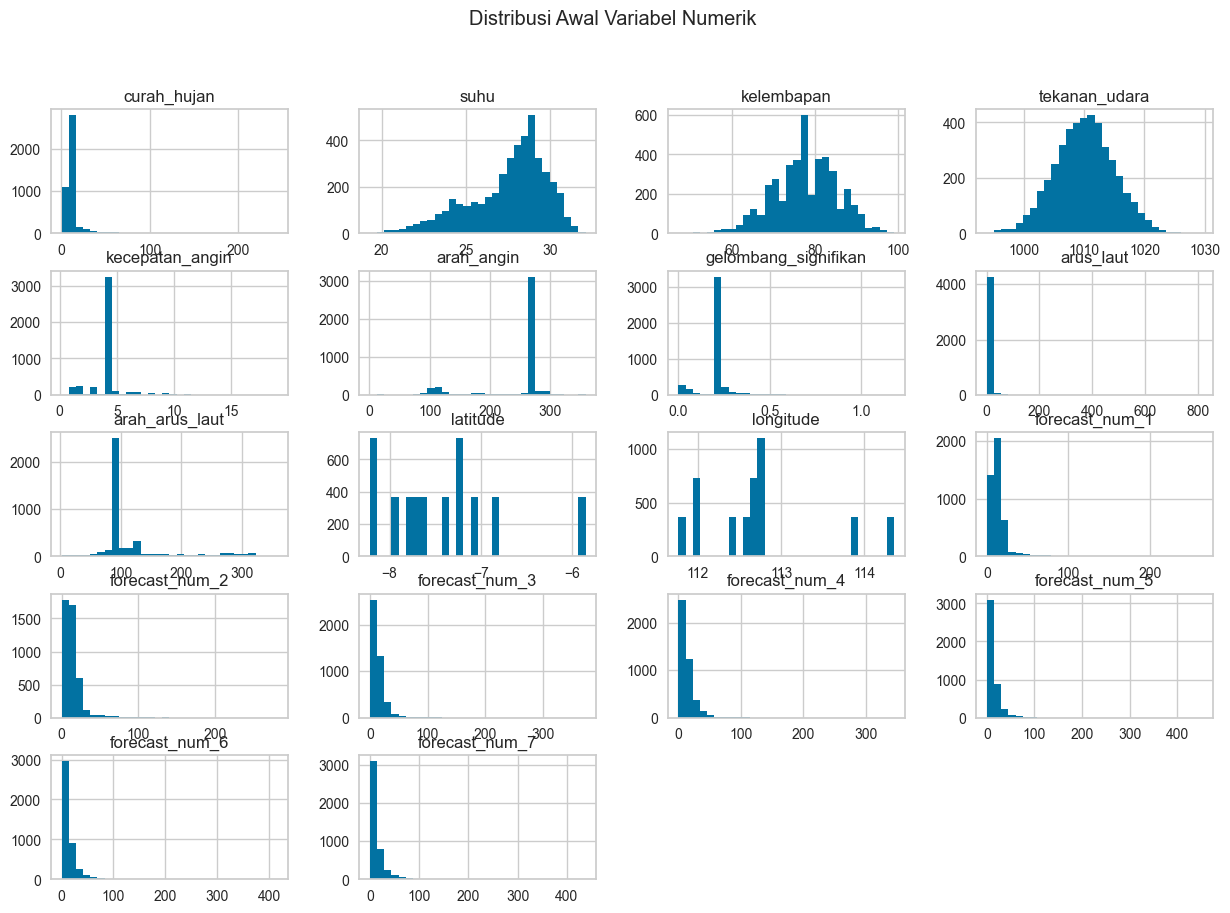

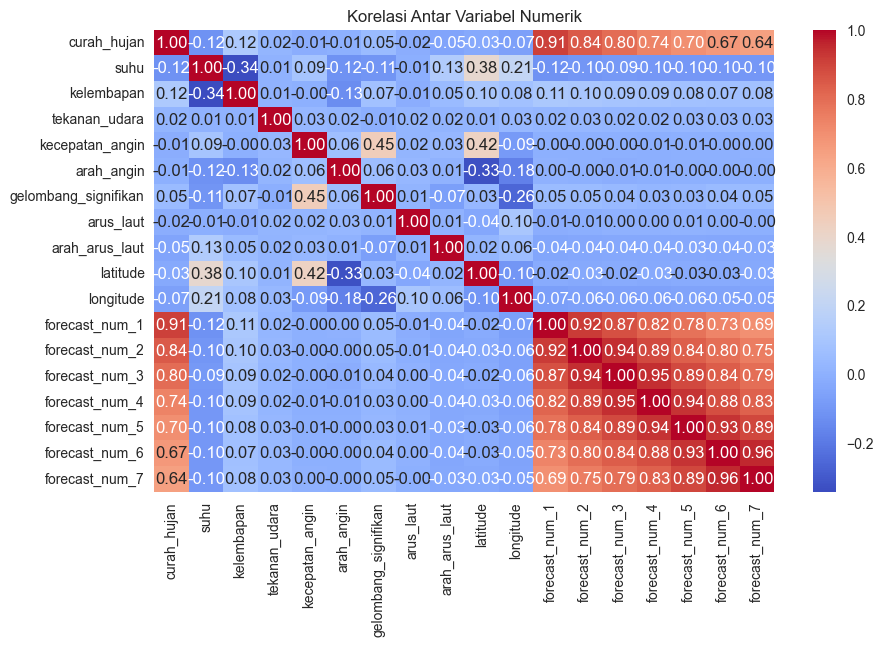

In [23]:
def eda_numerik(data, bins=30, figsize_hist=(15,10), figsize_corr=(10,6), cmap="coolwarm"):
    numeric_cols = data.select_dtypes(include='number').columns
    if len(numeric_cols) == 0:
        print("Tidak ada kolom numerik untuk dianalisis.")
        return
    
    print("=== Statistik Deskriptif Kolom Numerik ===")
    display(data[numeric_cols].describe().round(2))
    
    data[numeric_cols].hist(bins=bins, figsize=figsize_hist)
    plt.suptitle("Distribusi Awal Variabel Numerik")
    plt.show()
    
    corr_matrix = data[numeric_cols].corr()
    plt.figure(figsize=figsize_corr)
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap=cmap)
    plt.title("Korelasi Antar Variabel Numerik")
    plt.show()
    
    return corr_matrix

corr_matrix = eda_numerik(data)


KLASIFIKASI BERDASARKAN CURAH HUJAN (mm)

In [24]:
def klasifikasi_hujan(ch):
    if ch <= 4:
        return "Tidak Hujan"
    elif ch <= 20:
        return "Ringan"
    elif ch <= 50:
        return "Sedang"
    elif ch <= 100:
        return "Lebat"
    else:
        return "Sangat Lebat"

data["intensitas_hujan"] = data["curah_hujan"].apply(klasifikasi_hujan)

for i in range(1, 8):
    kolom_forecast = f"forecast_num_{i}"
    kolom_intensitas = f"intensitas_forecast_{i}"
    if kolom_forecast in data.columns:
        data[kolom_intensitas] = data[kolom_forecast].apply(klasifikasi_hujan)

print("Variabel 'intensitas_hujan' dan 'intensitas_forecast_1-7' berhasil ditambahkan:")
display(data)

Variabel 'intensitas_hujan' dan 'intensitas_forecast_1-7' berhasil ditambahkan:


,tanggal,stasiun,curah_hujan,suhu,kelembapan,tekanan_udara,kecepatan_angin,arah_angin,gelombang_signifikan,arus_laut,arah_arus_laut,latitude,longitude,forecast_num_1,forecast_num_2,forecast_num_3,forecast_num_4,forecast_num_5,forecast_num_6,forecast_num_7,intensitas_hujan,intensitas_forecast_1,intensitas_forecast_2,intensitas_forecast_3,intensitas_forecast_4,intensitas_forecast_5,intensitas_forecast_6,intensitas_forecast_7
0,2024-01-01,Stasiun Meteorologi Juanda,3.800000,29.9,83.0,1012.48,1.95339,99.0,0.221878,0.715440,78.0,-7.372351,112.781699,3.800000,3.800000,3.800000,3.800000,3.800000,3.800000,3.800000,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan
1,2024-01-01,Stasiun Meteorologi Perak 1,0.600000,29.9,78.0,1009.31,1.37082,89.0,0.221878,0.556430,79.0,-7.223151,112.724061,0.600000,0.600000,0.600000,0.600000,0.600000,0.600000,0.600000,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan
2,2024-01-01,Stasiun Meteorologi Maritim Tanjung Perak,0.200000,30.2,77.0,1013.24,1.40119,87.0,0.221878,0.556430,79.0,-7.204321,112.735102,0.200000,0.200000,0.200000,0.200000,0.200000,0.200000,0.200000,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan
3,2024-01-01,Stasiun Meteorologi Trunojoyo,13.947431,27.3,91.0,1017.62,5.00000,98.0,0.005190,2.000000,123.0,-7.039760,113.914000,13.947431,13.947431,13.947431,13.947431,13.947431,13.947431,13.947431,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan
4,2024-01-01,Stasiun Meteorologi Tuban,13.947431,30.1,76.0,1008.83,2.00000,101.0,0.036500,1.000000,45.0,-6.822900,111.991770,13.947431,13.947431,13.947431,13.947431,13.947431,13.947431,13.947431,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4387,2024-12-31,Stasiun Meteorologi Dhoho,13.900000,26.3,89.0,1002.84,6.00000,86.0,0.258000,9.169743,90.0,-7.754870,111.946900,7.520000,8.330000,8.410000,7.880000,7.010000,11.240000,8.470000,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan
4388,2024-12-31,Stasiun Klimatologi Jawa Timur,4.800000,24.6,84.0,1010.73,1.00000,36.0,0.314390,9.169743,90.0,-7.900800,112.597900,3.880000,5.390000,5.410000,3.350000,2.960000,3.080000,3.910000,Ringan,Tidak Hujan,Ringan,Ringan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan
4389,2024-12-31,Stasiun Geofisika Malang,46.500000,26.1,86.0,1012.93,3.00000,21.0,0.824640,9.169743,90.0,-8.150000,112.450000,18.360000,20.990000,24.880000,22.440000,19.140000,22.980000,18.740000,Sedang,Ringan,Sedang,Sedang,Sedang,Ringan,Sedang,Ringan
4390,2024-12-31,Stasiun Geofisika Nganjuk,38.000000,24.1,86.0,1012.57,7.00000,94.0,0.258000,9.169743,90.0,-7.734860,111.766820,69.510000,79.170000,91.890000,111.900000,112.700000,152.050000,198.030000,Sedang,Lebat,Lebat,Lebat,Sangat Lebat,Sangat Lebat,Sangat Lebat,Sangat Lebat


SETUP PYCARET UNTUK PERMODELAN BEST PARAMETER

In [25]:
clf_setup = setup(
    data=data,
    target='intensitas_hujan',
    normalize=True,
    session_id=123,
    remove_multicollinearity=True,
    multicollinearity_threshold=0.9,
    train_size=0.8,
    verbose=False
)

print("Setup selesai. Model siap dibandingkan dan dilatih.")

Setup selesai. Model siap dibandingkan dan dilatih.


BANDINGKAN BEBERAPA MODEL

In [26]:
best_models = compare_models(sort='Accuracy', n_select=5)

print("5 Model Terbaik Berdasarkan Akurasi:")
best_models

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.9257,0.0000,0.9257,0.9207,0.9211,0.8333,0.8342,0.1860
catboost,CatBoost Classifier,0.9248,0.0000,0.9248,0.9207,0.9217,0.8279,0.8294,16.9440
lr,Logistic Regression,0.9246,0.0000,0.9246,0.9234,0.9226,0.8312,0.8318,0.3850
et,Extra Trees Classifier,0.9223,0.0000,0.9223,0.9167,0.9186,0.8244,0.8251,0.9480
rf,Random Forest Classifier,0.9191,0.0000,0.9191,0.9158,0.9156,0.8139,0.8161,0.4280
gbc,Gradient Boosting Classifier,0.9180,0.0000,0.9180,0.9166,0.9159,0.8125,0.8141,3.8820
xgboost,Extreme Gradient Boosting,0.9180,0.0000,0.9180,0.9149,0.9151,0.8107,0.8128,3.2440
lightgbm,Light Gradient Boosting Machine,0.9146,0.0000,0.9146,0.9109,0.9113,0.8029,0.8050,0.9530
lda,Linear Discriminant Analysis,0.9100,0.0000,0.9100,0.9265,0.9158,0.8116,0.8150,0.6570
svm,SVM - Linear Kernel,0.9083,0.0000,0.9083,0.9062,0.9056,0.7933,0.7946,0.2550


5 Model Terbaik Berdasarkan Akurasi:


[RidgeClassifier(alpha=1.0, class_weight=None, copy_X=True, fit_intercept=True,
                 max_iter=None, positive=False, random_state=123, solver='auto',
                 tol=0.0001),
 LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                    intercept_scaling=1, l1_ratio=None, max_iter=1000,
                    multi_class='auto', n_jobs=None, penalty='l2',
                    random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                    warm_start=False),
 ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                      criterion='gini', max_depth=None, max_features='sqrt',
                      max_leaf_nodes=None, max_samples=None,
                      min_impurity_decrease=0.0, min_samples_leaf=1,
                      min_samples_split=2, min_weight_fraction_leaf=0.0,
                      monotonic_cst=None, n_estimators=100, n_jobs=-1,
                      oob_score=False, random_state=1

PILIH DAN LATIH RIDGE CLASSIFIER

In [27]:
ridge_model = create_model('ridge')
tuned_ridge = tune_model(ridge_model)
final_ridge = finalize_model(tuned_ridge)

print("Model Ridge Classifier sudah dilatih dan difinalisasi.")

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9290,0.0000,0.9290,0.9240,0.9218,0.8376,0.8398
1,0.9119,0.0000,0.9119,0.8992,0.9012,0.7987,0.8009
2,0.9091,0.0000,0.9091,0.9049,0.9034,0.7984,0.7997
3,0.9231,0.0000,0.9231,0.9143,0.9180,0.8248,0.8255
4,0.9345,0.0000,0.9345,0.9346,0.9340,0.8535,0.8535
5,0.9202,0.0000,0.9202,0.9168,0.9180,0.8245,0.8250
6,0.9316,0.0000,0.9316,0.9286,0.9282,0.8487,0.8493
7,0.9088,0.0000,0.9088,0.8995,0.9029,0.7956,0.7963
8,0.9630,0.0000,0.9630,0.9630,0.9615,0.9173,0.9178


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
Model Ridge Classifier sudah dilatih dan difinalisasi.


EVALUASI MODEL RIDGE CLASSIFIER

In [28]:
evaluate_model(final_ridge)

ridge_results = pull()
print("Hasil evaluasi Ridge Classifier:")
print(ridge_results)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Hasil evaluasi Ridge Classifier:
      Accuracy  AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                       
0       0.9290  0.0  0.9290  0.9240  0.9218  0.8376  0.8398
1       0.9119  0.0  0.9119  0.8992  0.9012  0.7987  0.8009
2       0.9091  0.0  0.9091  0.9049  0.9034  0.7984  0.7997
3       0.9231  0.0  0.9231  0.9143  0.9180  0.8248  0.8255
4       0.9345  0.0  0.9345  0.9346  0.9340  0.8535  0.8535
5       0.9202  0.0  0.9202  0.9168  0.9180  0.8245  0.8250
6       0.9316  0.0  0.9316  0.9286  0.9282  0.8487  0.8493
7       0.9088  0.0  0.9088  0.8995  0.9029  0.7956  0.7963
8       0.9630  0.0  0.9630  0.9630  0.9615  0.9173  0.9178
9       0.9259  0.0  0.9259  0.9220  0.9220  0.8340  0.8347
Mean    0.9257  0.0  0.9257  0.9207  0.9211  0.8333  0.8342
Std     0.0152  0.0  0.0152  0.0181  0.0170  0.0342  0.0339


SIMPAN MODEL RIDGE CLASSIFIER

In [29]:
save_model(final_ridge, 'model_ridge_classifier_intensitas_hujan')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['curah_hujan', 'suhu',
                                              'kelembapan', 'tekanan_udara',
                                              'kecepatan_angin', 'arah_angin',
                                              'gelombang_signifikan',
                                              'arus_laut', 'arah_arus_laut',
                                              'latitu...
                                     transformer=RemoveMulticollinearity(threshold=0.9))),
                 ('normalize',
                  TransformerWrapper(exclude=None, include=None,
                                     transformer=StandardScaler(

PILIH DAN LATIH CATBOOST CLASSIFIER

In [30]:
catboost_model = create_model('catboost')
tuned_catboost = tune_model(catboost_model)
final_catboost = finalize_model(tuned_catboost)

print("Model CatBoost Classifier sudah dilatih dan difinalisasi.")

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8977,0.0000,0.8977,0.8920,0.8925,0.7625,0.7654
1,0.9233,0.0000,0.9233,0.9156,0.9182,0.8242,0.8258
2,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,0.9231,0.0000,0.9231,0.9194,0.9204,0.8232,0.8246
4,0.9231,0.0000,0.9231,0.9228,0.9215,0.8223,0.8247
5,0.9145,0.0000,0.9145,0.9110,0.9125,0.8079,0.8081
6,0.9288,0.0000,0.9288,0.9240,0.9247,0.8407,0.8413
7,0.8803,0.0000,0.8803,0.8775,0.8765,0.7201,0.7242
8,0.9430,0.0000,0.9430,0.9379,0.9403,0.8728,0.8731


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9375,0.0000,0.9375,0.9330,0.9333,0.8588,0.8597
1,0.9233,0.0000,0.9233,0.9143,0.9177,0.8275,0.8282
2,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,0.9202,0.0000,0.9202,0.9154,0.9176,0.8213,0.8214
4,0.9288,0.0000,0.9288,0.9256,0.9268,0.8394,0.8397
5,0.9202,0.0000,0.9202,0.9113,0.9143,0.8200,0.8208
6,0.9373,0.0000,0.9373,0.9339,0.9338,0.8607,0.8613
7,0.9060,0.0000,0.9060,0.9072,0.9042,0.7909,0.7913
8,0.9516,0.0000,0.9516,0.9497,0.9488,0.8910,0.8919


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Model CatBoost Classifier sudah dilatih dan difinalisasi.


EVALUASI MODEL CATBOOST CLASSIFIER

In [31]:
evaluate_model(final_catboost)

catboost_results = pull()
print("Hasil evaluasi CatBoost Classifier:")
print(catboost_results)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Hasil evaluasi CatBoost Classifier:
      Accuracy  AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                       
0       0.9375  0.0  0.9375  0.9330  0.9333  0.8588  0.8597
1       0.9233  0.0  0.9233  0.9143  0.9177  0.8275  0.8282
2       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
3       0.9202  0.0  0.9202  0.9154  0.9176  0.8213  0.8214
4       0.9288  0.0  0.9288  0.9256  0.9268  0.8394  0.8397
5       0.9202  0.0  0.9202  0.9113  0.9143  0.8200  0.8208
6       0.9373  0.0  0.9373  0.9339  0.9338  0.8607  0.8613
7       0.9060  0.0  0.9060  0.9072  0.9042  0.7909  0.7913
8       0.9516  0.0  0.9516  0.9497  0.9488  0.8910  0.8919
9       0.9174  0.0  0.9174  0.9047  0.9097  0.8123  0.8134
Mean    0.9342  0.0  0.9342  0.9295  0.9306  0.8522  0.8528
Std     0.0250  0.0  0.0250  0.0270  0.0263  0.0562  0.0561


SIMPAN MODEL CATBOOST CLASSIFIER

In [32]:
save_model(final_catboost, 'model_catboost_classifier_intensitas_hujan')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['curah_hujan', 'suhu',
                                              'kelembapan', 'tekanan_udara',
                                              'kecepatan_angin', 'arah_angin',
                                              'gelombang_signifikan',
                                              'arus_laut', 'arah_arus_laut',
                                              'latitu...
                                                               verbose=0))),
                 ('remove_multicollinearity',
                  TransformerWrapper(exclude=[], include=None,
                                     transformer=RemoveMulticolli

PILIH DAN LATIH LOGISTIC REGRESSION

In [33]:
lr_model = create_model('lr')
tuned_lr = tune_model(lr_model)
final_lr = finalize_model(tuned_lr)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9176,0.0000,0.9176,0.9128,0.9129,0.8127,0.8140
1,0.9261,0.0000,0.9261,0.9204,0.9224,0.8340,0.8345
2,0.9432,0.0000,0.9432,0.9477,0.9435,0.8751,0.8756
3,0.9202,0.0000,0.9202,0.9213,0.9186,0.8190,0.8195
4,0.9145,0.0000,0.9145,0.9149,0.9131,0.8037,0.8052
5,0.9117,0.0000,0.9117,0.9085,0.9097,0.8056,0.8061
6,0.9345,0.0000,0.9345,0.9358,0.9335,0.8562,0.8568
7,0.9031,0.0000,0.9031,0.8981,0.9003,0.7839,0.7841
8,0.9487,0.0000,0.9487,0.9512,0.9488,0.8870,0.8872


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9148,0.0000,0.9148,0.9077,0.9095,0.8059,0.8072
1,0.9290,0.0000,0.9290,0.9216,0.9247,0.8411,0.8414
2,0.9176,0.0000,0.9176,0.9194,0.9168,0.8191,0.8198
3,0.9288,0.0000,0.9288,0.9217,0.9245,0.8368,0.8377
4,0.9345,0.0000,0.9345,0.9354,0.9339,0.8531,0.8532
5,0.9202,0.0000,0.9202,0.9156,0.9173,0.8236,0.8241
6,0.9373,0.0000,0.9373,0.9354,0.9346,0.8613,0.8619
7,0.9031,0.0000,0.9031,0.8996,0.9010,0.7840,0.7842
8,0.9573,0.0000,0.9573,0.9565,0.9561,0.9051,0.9052


Fitting 10 folds for each of 10 candidates, totalling 100 fits


EVALUASI MODEL LOGISTIC REGRESSION

In [34]:
evaluate_model(final_lr)

lr_results = pull()
print("Hasil Evaluasi Logistic Regression:")
print(lr_results)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Hasil Evaluasi Logistic Regression:
      Accuracy  AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                       
0       0.9148  0.0  0.9148  0.9077  0.9095  0.8059  0.8072
1       0.9290  0.0  0.9290  0.9216  0.9247  0.8411  0.8414
2       0.9176  0.0  0.9176  0.9194  0.9168  0.8191  0.8198
3       0.9288  0.0  0.9288  0.9217  0.9245  0.8368  0.8377
4       0.9345  0.0  0.9345  0.9354  0.9339  0.8531  0.8532
5       0.9202  0.0  0.9202  0.9156  0.9173  0.8236  0.8241
6       0.9373  0.0  0.9373  0.9354  0.9346  0.8613  0.8619
7       0.9031  0.0  0.9031  0.8996  0.9010  0.7840  0.7842
8       0.9573  0.0  0.9573  0.9565  0.9561  0.9051  0.9052
9       0.9259  0.0  0.9259  0.9225  0.9233  0.8348  0.8350
Mean    0.9268  0.0  0.9268  0.9236  0.9242  0.8365  0.8370
Std     0.0139  0.0  0.0139  0.0151  0.0144  0.0313  0.0312


SIMPAN MODEL LOGISTIC REGRESSION

In [35]:
save_model(final_lr, 'model_logistic_regression_intensitas_hujan')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['curah_hujan', 'suhu',
                                              'kelembapan', 'tekanan_udara',
                                              'kecepatan_angin', 'arah_angin',
                                              'gelombang_signifikan',
                                              'arus_laut', 'arah_arus_laut',
                                              'latitu...
                  TransformerWrapper(exclude=None, include=None,
                                     transformer=StandardScaler(copy=True,
                                                                with_mean=True,
                               

PILIH DAN LATIH EXTRA TREES CLASSIFIER

In [36]:
et_model = create_model('et')
tuned_et = tune_model(et_model)
final_et = finalize_model(tuned_et)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9062,0.0000,0.9062,0.8976,0.9003,0.7844,0.7863
1,0.9176,0.0000,0.9176,0.9085,0.9112,0.8130,0.8141
2,0.9432,0.0000,0.9432,0.9438,0.9428,0.8746,0.8748
3,0.9174,0.0000,0.9174,0.9123,0.9143,0.8105,0.8116
4,0.9288,0.0000,0.9288,0.9280,0.9278,0.8390,0.8394
5,0.9174,0.0000,0.9174,0.9124,0.9142,0.8160,0.8164
6,0.9174,0.0000,0.9174,0.9135,0.9147,0.8162,0.8164
7,0.9003,0.0000,0.9003,0.8906,0.8941,0.7730,0.7742
8,0.9487,0.0000,0.9487,0.9414,0.9443,0.8842,0.8850


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8949,0.0000,0.8949,0.8925,0.8911,0.7557,0.7592
1,0.9176,0.0000,0.9176,0.9107,0.9139,0.8142,0.8146
2,0.9574,0.0000,0.9574,0.9604,0.9576,0.9064,0.9067
3,0.9031,0.0000,0.9031,0.9015,0.9002,0.7750,0.7778
4,0.9174,0.0000,0.9174,0.9186,0.9160,0.8085,0.8114
5,0.9117,0.0000,0.9117,0.9101,0.9107,0.8038,0.8038
6,0.9316,0.0000,0.9316,0.9312,0.9309,0.8471,0.8475
7,0.8860,0.0000,0.8860,0.8844,0.8833,0.7359,0.7393
8,0.9402,0.0000,0.9402,0.9366,0.9382,0.8663,0.8665


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


EVALUASI MODEL EXTRA TREES CLASSIFIER

In [37]:
evaluate_model(final_et)

et_results = pull()
print("Hasil Evaluasi Extra Trees:")
print(et_results)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Hasil Evaluasi Extra Trees:
      Accuracy  AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                       
0       0.8949  0.0  0.8949  0.8925  0.8911  0.7557  0.7592
1       0.9176  0.0  0.9176  0.9107  0.9139  0.8142  0.8146
2       0.9574  0.0  0.9574  0.9604  0.9576  0.9064  0.9067
3       0.9031  0.0  0.9031  0.9015  0.9002  0.7750  0.7778
4       0.9174  0.0  0.9174  0.9186  0.9160  0.8085  0.8114
5       0.9117  0.0  0.9117  0.9101  0.9107  0.8038  0.8038
6       0.9316  0.0  0.9316  0.9312  0.9309  0.8471  0.8475
7       0.8860  0.0  0.8860  0.8844  0.8833  0.7359  0.7393
8       0.9402  0.0  0.9402  0.9366  0.9382  0.8663  0.8665
9       0.9060  0.0  0.9060  0.8996  0.9009  0.7825  0.7848
Mean    0.9166  0.0  0.9166  0.9145  0.9143  0.8095  0.8112
Std     0.0204  0.0  0.0204  0.0217  0.0215  0.0493  0.0482


SIMPAN MODEL EXTRA TREES CLASSIFIER

In [38]:
save_model(final_et, 'model_extra_trees_clssifier_intensitas_hujan')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['curah_hujan', 'suhu',
                                              'kelembapan', 'tekanan_udara',
                                              'kecepatan_angin', 'arah_angin',
                                              'gelombang_signifikan',
                                              'arus_laut', 'arah_arus_laut',
                                              'latitu...
                  ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0,
                                       class_weight=None, criterion='gini',
                                       max_depth=None, max_features='sqrt',
                            

PILIH DAN LATIH RANDOM FOREST CLASSIFIER

In [39]:
rf_model = create_model('rf')
tuned_rf = tune_model(rf_model)
final_rf = finalize_model(tuned_rf)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8949,0.0000,0.8949,0.8912,0.8904,0.7545,0.7583
1,0.9176,0.0000,0.9176,0.9126,0.9100,0.8076,0.8117
2,0.9773,0.0000,0.9773,0.9809,0.9772,0.9491,0.9497
3,0.9117,0.0000,0.9117,0.9081,0.9087,0.7956,0.7978
4,0.9202,0.0000,0.9202,0.9198,0.9185,0.8149,0.8177
5,0.9117,0.0000,0.9117,0.9083,0.9098,0.8044,0.8045
6,0.9231,0.0000,0.9231,0.9213,0.9214,0.8271,0.8277
7,0.8803,0.0000,0.8803,0.8746,0.8750,0.7188,0.7235
8,0.9430,0.0000,0.9430,0.9370,0.9385,0.8697,0.8713


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8864,0.0000,0.8864,0.8896,0.8868,0.7446,0.7455
1,0.9176,0.0000,0.9176,0.9119,0.9144,0.8137,0.8143
2,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,0.8974,0.0000,0.8974,0.8972,0.8960,0.7640,0.7659
4,0.9231,0.0000,0.9231,0.9250,0.9222,0.8233,0.8255
5,0.9060,0.0000,0.9060,0.8862,0.8922,0.7797,0.7833
6,0.9202,0.0000,0.9202,0.9196,0.9191,0.8203,0.8210
7,0.8860,0.0000,0.8860,0.8927,0.8881,0.7453,0.7462
8,0.9345,0.0000,0.9345,0.9304,0.9321,0.8525,0.8530


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


EVALUASI MODEL RANDOM FOREST CLASSIFIER

In [40]:
evaluate_model(final_rf)

rf_results = pull()
print("Hasil Evaluasi Random Forest:")
print(rf_results)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Hasil Evaluasi Random Forest:
      Accuracy  AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                       
0       0.8864  0.0  0.8864  0.8896  0.8868  0.7446  0.7455
1       0.9176  0.0  0.9176  0.9119  0.9144  0.8137  0.8143
2       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
3       0.8974  0.0  0.8974  0.8972  0.8960  0.7640  0.7659
4       0.9231  0.0  0.9231  0.9250  0.9222  0.8233  0.8255
5       0.9060  0.0  0.9060  0.8862  0.8922  0.7797  0.7833
6       0.9202  0.0  0.9202  0.9196  0.9191  0.8203  0.8210
7       0.8860  0.0  0.8860  0.8927  0.8881  0.7453  0.7462
8       0.9345  0.0  0.9345  0.9304  0.9321  0.8525  0.8530
9       0.9145  0.0  0.9145  0.9145  0.9131  0.8047  0.8065
Mean    0.9186  0.0  0.9186  0.9167  0.9164  0.8148  0.8161
Std     0.0310  0.0  0.0310  0.0314  0.0316  0.0704  0.0699


SIMPAN MODEL RANDOM FOREST CLASSIFIER

In [41]:
save_model(final_rf, 'model_random_forest_intensitas_hujan')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['curah_hujan', 'suhu',
                                              'kelembapan', 'tekanan_udara',
                                              'kecepatan_angin', 'arah_angin',
                                              'gelombang_signifikan',
                                              'arus_laut', 'arah_arus_laut',
                                              'latitu...
                  RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                         class_weight=None, criterion='gini',
                                         max_depth=None, max_features='sqrt',
                       

PILIH DAN LATIH GRADIENT BOOSTING CLASSIFIER

In [42]:
gbc_model = create_model('gbc')
tuned_gbc= tune_model(gbc_model)
final_gbc = finalize_model(tuned_gbc)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8892,0.0000,0.8892,0.8860,0.8855,0.7426,0.7460
1,0.9205,0.0000,0.9205,0.9176,0.9178,0.8178,0.8192
2,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,0.9060,0.0000,0.9060,0.9033,0.9036,0.7833,0.7851
4,0.9060,0.0000,0.9060,0.9124,0.9054,0.7865,0.7885
5,0.9174,0.0000,0.9174,0.9150,0.9161,0.8171,0.8173
6,0.9231,0.0000,0.9231,0.9221,0.9216,0.8279,0.8284
7,0.8689,0.0000,0.8689,0.8653,0.8649,0.6945,0.6980
8,0.9345,0.0000,0.9345,0.9330,0.9334,0.8522,0.8528


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9205,0.0000,0.9205,0.9171,0.9126,0.8122,0.8175
1,0.9176,0.0000,0.9176,0.9088,0.9085,0.8051,0.8102
2,0.9744,0.0000,0.9744,0.9755,0.9739,0.9429,0.9431
3,0.9088,0.0000,0.9088,0.9025,0.9038,0.7852,0.7891
4,0.9174,0.0000,0.9174,0.9146,0.9132,0.8051,0.8099
5,0.9145,0.0000,0.9145,0.9119,0.9130,0.8087,0.8088
6,0.9145,0.0000,0.9145,0.9067,0.9062,0.8022,0.8055
7,0.8832,0.0000,0.8832,0.8747,0.8749,0.7199,0.7280
8,0.9373,0.0000,0.9373,0.9348,0.9321,0.8540,0.8575


Fitting 10 folds for each of 10 candidates, totalling 100 fits


EVALUASI MODEL GRADIENT BOOSTING CLASSIFIER

In [43]:
evaluate_model(final_gbc)

gbc_results = pull()
print("Hasil Evaluasi Gradient Boosting Classifier:")
print(gbc_results)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Hasil Evaluasi Gradient Boosting Classifier:
      Accuracy  AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                       
0       0.9205  0.0  0.9205  0.9171  0.9126  0.8122  0.8175
1       0.9176  0.0  0.9176  0.9088  0.9085  0.8051  0.8102
2       0.9744  0.0  0.9744  0.9755  0.9739  0.9429  0.9431
3       0.9088  0.0  0.9088  0.9025  0.9038  0.7852  0.7891
4       0.9174  0.0  0.9174  0.9146  0.9132  0.8051  0.8099
5       0.9145  0.0  0.9145  0.9119  0.9130  0.8087  0.8088
6       0.9145  0.0  0.9145  0.9067  0.9062  0.8022  0.8055
7       0.8832  0.0  0.8832  0.8747  0.8749  0.7199  0.7280
8       0.9373  0.0  0.9373  0.9348  0.9321  0.8540  0.8575
9       0.9003  0.0  0.9003  0.8862  0.8904  0.7637  0.7692
Mean    0.9189  0.0  0.9189  0.9133  0.9129  0.8099  0.8139
Std     0.0228  0.0  0.0228  0.0260  0.0249  0.0553  0.0536


SIMPAN MODEL GRADIENT BOOSTING CLASSIFIER

In [44]:
save_model(final_gbc, 'model_gradient_boosting_classifier_intensitas_hujan')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['curah_hujan', 'suhu',
                                              'kelembapan', 'tekanan_udara',
                                              'kecepatan_angin', 'arah_angin',
                                              'gelombang_signifikan',
                                              'arus_laut', 'arah_arus_laut',
                                              'latitu...
                                             criterion='friedman_mse', init=None,
                                             learning_rate=0.01, loss='log_loss',
                                             max_depth=7, max_features='sqrt',
        

PILIH DAN LATIH EXTREME GRADIENT BOOSING

In [45]:
xgboost_model = create_model('xgboost')
tuned_xgboost = tune_model(xgboost_model)
final_xgboost = finalize_model(tuned_xgboost)

print("Model Extreme Gradient Boosting sudah dilatih dan difinalisasi.")

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8864,0.0000,0.8864,0.8819,0.8824,0.7362,0.7389
1,0.9205,0.0000,0.9205,0.9130,0.9161,0.8180,0.8193
2,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,0.9088,0.0000,0.9088,0.9072,0.9057,0.7857,0.7898
4,0.9117,0.0000,0.9117,0.9111,0.9094,0.7943,0.7975
5,0.9117,0.0000,0.9117,0.9058,0.9086,0.8001,0.8004
6,0.9231,0.0000,0.9231,0.9208,0.9211,0.8271,0.8277
7,0.8803,0.0000,0.8803,0.8758,0.8756,0.7191,0.7238
8,0.9316,0.0000,0.9316,0.9303,0.9300,0.8445,0.8456


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9148,0.0000,0.9148,0.9101,0.9082,0.8017,0.8052
1,0.9261,0.0000,0.9261,0.9176,0.9165,0.8299,0.8326
2,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,0.9288,0.0000,0.9288,0.9245,0.9264,0.8379,0.8385
4,0.9373,0.0000,0.9373,0.9328,0.9336,0.8555,0.8572
5,0.9117,0.0000,0.9117,0.9046,0.9074,0.8026,0.8030
6,0.9316,0.0000,0.9316,0.9246,0.9249,0.8451,0.8466
7,0.9088,0.0000,0.9088,0.9000,0.9039,0.7937,0.7944
8,0.9459,0.0000,0.9459,0.9415,0.9420,0.8769,0.8782


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Model Extreme Gradient Boosting sudah dilatih dan difinalisasi.


EVALUASI MODEL EXTREME GRADIENT BOOSTING

In [46]:
evaluate_model(final_xgboost)

xgboost_results = pull()
print("Hasil evaluasi Extreme Gradient Boosting:")
print(xgboost_results)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Hasil evaluasi Extreme Gradient Boosting:
      Accuracy  AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                       
0       0.9148  0.0  0.9148  0.9101  0.9082  0.8017  0.8052
1       0.9261  0.0  0.9261  0.9176  0.9165  0.8299  0.8326
2       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
3       0.9288  0.0  0.9288  0.9245  0.9264  0.8379  0.8385
4       0.9373  0.0  0.9373  0.9328  0.9336  0.8555  0.8572
5       0.9117  0.0  0.9117  0.9046  0.9074  0.8026  0.8030
6       0.9316  0.0  0.9316  0.9246  0.9249  0.8451  0.8466
7       0.9088  0.0  0.9088  0.9000  0.9039  0.7937  0.7944
8       0.9459  0.0  0.9459  0.9415  0.9420  0.8769  0.8782
9       0.9174  0.0  0.9174  0.9075  0.9116  0.8129  0.8138
Mean    0.9322  0.0  0.9322  0.9263  0.9274  0.8456  0.8470
Std     0.0252  0.0  0.0252  0.0275  0.0269  0.0572  0.0568


SIMPAN MODEL EXTREME GRADIENT BOOSTING

In [47]:
save_model(final_xgboost, 'model_extreme_gradient_boosting_intensitas_hujan')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['curah_hujan', 'suhu',
                                              'kelembapan', 'tekanan_udara',
                                              'kecepatan_angin', 'arah_angin',
                                              'gelombang_signifikan',
                                              'arus_laut', 'arah_arus_laut',
                                              'latitu...
                                grow_policy=None, importance_type=None,
                                interaction_constraints=None,
                                learning_rate=1e-06, max_bin=None,
                                max_cat_threshold=

PILIH DAN LATIH LIGHT GRADIENT BOOSTING MACHINE

In [48]:
lightgbm_model = create_model('lightgbm')
tuned_lightgbm = tune_model(lightgbm_model)
final_lightgbm = finalize_model(tuned_lightgbm)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8807,0.0000,0.8807,0.8789,0.8777,0.7241,0.7263
1,0.9176,0.0000,0.9176,0.9112,0.9137,0.8117,0.8131
2,0.9972,0.0000,0.9972,0.9981,0.9974,0.9937,0.9937
3,0.9174,0.0000,0.9174,0.9169,0.9158,0.8081,0.8107
4,0.9031,0.0000,0.9031,0.9035,0.9004,0.7722,0.7770
5,0.9088,0.0000,0.9088,0.9040,0.9062,0.7946,0.7948
6,0.9145,0.0000,0.9145,0.9121,0.9129,0.8079,0.8083
7,0.8718,0.0000,0.8718,0.8628,0.8646,0.6962,0.7018
8,0.9316,0.0000,0.9316,0.9250,0.9280,0.8450,0.8458


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9062,0.0000,0.9062,0.9012,0.9025,0.7854,0.7867
1,0.9318,0.0000,0.9318,0.9291,0.9297,0.8466,0.8469
2,0.9972,0.0000,0.9972,0.9974,0.9968,0.9937,0.9937
3,0.9231,0.0000,0.9231,0.9204,0.9216,0.8264,0.8267
4,0.9345,0.0000,0.9345,0.9339,0.9335,0.8500,0.8512
5,0.9117,0.0000,0.9117,0.9070,0.9089,0.8043,0.8045
6,0.9316,0.0000,0.9316,0.9273,0.9286,0.8481,0.8485
7,0.8860,0.0000,0.8860,0.8815,0.8818,0.7349,0.7380
8,0.9487,0.0000,0.9487,0.9430,0.9457,0.8861,0.8862


Fitting 10 folds for each of 10 candidates, totalling 100 fits


EVALUASI MODEL LIGHT GRADIENT BOOSTING MACHINE

In [49]:
evaluate_model(final_lightgbm)

lightgbm_results = pull()
print("Hasil Evaluasi LightGBM:")
print(lightgbm_results)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Hasil Evaluasi LightGBM:
      Accuracy  AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                       
0       0.9062  0.0  0.9062  0.9012  0.9025  0.7854  0.7867
1       0.9318  0.0  0.9318  0.9291  0.9297  0.8466  0.8469
2       0.9972  0.0  0.9972  0.9974  0.9968  0.9937  0.9937
3       0.9231  0.0  0.9231  0.9204  0.9216  0.8264  0.8267
4       0.9345  0.0  0.9345  0.9339  0.9335  0.8500  0.8512
5       0.9117  0.0  0.9117  0.9070  0.9089  0.8043  0.8045
6       0.9316  0.0  0.9316  0.9273  0.9286  0.8481  0.8485
7       0.8860  0.0  0.8860  0.8815  0.8818  0.7349  0.7380
8       0.9487  0.0  0.9487  0.9430  0.9457  0.8861  0.8862
9       0.9174  0.0  0.9174  0.9102  0.9131  0.8120  0.8131
Mean    0.9288  0.0  0.9288  0.9251  0.9262  0.8387  0.8396
Std     0.0281  0.0  0.0281  0.0295  0.0291  0.0650  0.0643


SIMPAN MODEL LIGHT GRADIENT BOOSTING MACHINE

In [50]:
save_model(final_lightgbm, 'model_light_gradient_boosting_machine_intensitas_hujan')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['curah_hujan', 'suhu',
                                              'kelembapan', 'tekanan_udara',
                                              'kecepatan_angin', 'arah_angin',
                                              'gelombang_signifikan',
                                              'arus_laut', 'arah_arus_laut',
                                              'latitu...
                                 boosting_type='gbdt', class_weight=None,
                                 colsample_bytree=1.0, feature_fraction=0.4,
                                 importance_type='split', learning_rate=0.1,
                       

PILIH DAN LATIH LINEAR DISCRIMINANT ANALYSIS

In [51]:
lda_model = create_model('lda')
tuned_lda = tune_model(lda_model)
final_lda = finalize_model(tuned_lda)

print("Model Linear Discriminant Analysis sudah dilatih dan difinalisasi.")

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8892,0.0000,0.8892,0.9114,0.8982,0.7689,0.7723
1,0.9119,0.0000,0.9119,0.9220,0.9154,0.8129,0.8147
2,0.9432,0.0000,0.9432,0.9484,0.9441,0.8781,0.8798
3,0.9031,0.0000,0.9031,0.9206,0.9095,0.7958,0.7993
4,0.9231,0.0000,0.9231,0.9347,0.9270,0.8362,0.8384
5,0.9117,0.0000,0.9117,0.9244,0.9163,0.8133,0.8163
6,0.8803,0.0000,0.8803,0.9176,0.8938,0.7597,0.7684
7,0.8832,0.0000,0.8832,0.9068,0.8915,0.7581,0.7625
8,0.9231,0.0000,0.9231,0.9394,0.9278,0.8389,0.8423


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8949,0.0000,0.8949,0.9132,0.9024,0.7791,0.7816
1,0.9176,0.0000,0.9176,0.9256,0.9202,0.8243,0.8258
2,0.9176,0.0000,0.9176,0.9240,0.9192,0.8260,0.8285
3,0.9088,0.0000,0.9088,0.9262,0.9148,0.8086,0.8125
4,0.9288,0.0000,0.9288,0.9382,0.9321,0.8472,0.8486
5,0.9117,0.0000,0.9117,0.9183,0.9140,0.8104,0.8119
6,0.8974,0.0000,0.8974,0.9232,0.9070,0.7894,0.7946
7,0.8860,0.0000,0.8860,0.9077,0.8937,0.7631,0.7670
8,0.9202,0.0000,0.9202,0.9383,0.9255,0.8336,0.8375


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Model Linear Discriminant Analysis sudah dilatih dan difinalisasi.


EVALUASI MODEL LINEAR DISCRIMINANT ANALYSIS

In [52]:
evaluate_model(final_lda)

lda_results = pull()
print("Hasil evaluasi Linear Discriminant Analysis:")
print(lda_results)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Hasil evaluasi Linear Discriminant Analysis:
      Accuracy  AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                       
0       0.8949  0.0  0.8949  0.9132  0.9024  0.7791  0.7816
1       0.9176  0.0  0.9176  0.9256  0.9202  0.8243  0.8258
2       0.9176  0.0  0.9176  0.9240  0.9192  0.8260  0.8285
3       0.9088  0.0  0.9088  0.9262  0.9148  0.8086  0.8125
4       0.9288  0.0  0.9288  0.9382  0.9321  0.8472  0.8486
5       0.9117  0.0  0.9117  0.9183  0.9140  0.8104  0.8119
6       0.8974  0.0  0.8974  0.9232  0.9070  0.7894  0.7946
7       0.8860  0.0  0.8860  0.9077  0.8937  0.7631  0.7670
8       0.9202  0.0  0.9202  0.9383  0.9255  0.8336  0.8375
9       0.9316  0.0  0.9316  0.9380  0.9337  0.8534  0.8545
Mean    0.9115  0.0  0.9115  0.9253  0.9163  0.8135  0.8163
Std     0.0141  0.0  0.0141  0.0101  0.0121  0.0278  0.0271


SIMPAN MODEL LINEAR DISCRIMINANT ANALYSIS

In [53]:
save_model(final_lda, 'model_linear_discriminant_analysis_intensitas_hujan')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['curah_hujan', 'suhu',
                                              'kelembapan', 'tekanan_udara',
                                              'kecepatan_angin', 'arah_angin',
                                              'gelombang_signifikan',
                                              'arus_laut', 'arah_arus_laut',
                                              'latitu...
                                     transformer=RemoveMulticollinearity(threshold=0.9))),
                 ('normalize',
                  TransformerWrapper(exclude=None, include=None,
                                     transformer=StandardScaler(

PILIH DAN LATIH SUPPORT VECTOR MACHINE

In [54]:
svm_model = create_model('svm')
tuned_svm = tune_model(svm_model)
final_svm = finalize_model(tuned_svm)

print("Model Support Vector Machine sudah dilatih dan difinalisasi.")

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9062,0.0000,0.9062,0.9024,0.9030,0.7872,0.7882
1,0.9233,0.0000,0.9233,0.9176,0.9198,0.8284,0.8287
2,0.9290,0.0000,0.9290,0.9280,0.9269,0.8439,0.8444
3,0.8718,0.0000,0.8718,0.8801,0.8737,0.7102,0.7117
4,0.9060,0.0000,0.9060,0.8980,0.8996,0.7826,0.7846
5,0.9031,0.0000,0.9031,0.9013,0.9014,0.7873,0.7880
6,0.9145,0.0000,0.9145,0.9107,0.9099,0.8086,0.8097
7,0.8718,0.0000,0.8718,0.8717,0.8715,0.7134,0.7137
8,0.9544,0.0000,0.9544,0.9513,0.9526,0.8995,0.8996


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9205,0.0000,0.9205,0.9118,0.9147,0.8203,0.8212
1,0.9261,0.0000,0.9261,0.9205,0.9224,0.8355,0.8359
2,0.9176,0.0000,0.9176,0.9224,0.9167,0.8204,0.8217
3,0.9259,0.0000,0.9259,0.9222,0.9240,0.8349,0.8349
4,0.9373,0.0000,0.9373,0.9396,0.9378,0.8616,0.8617
5,0.9231,0.0000,0.9231,0.9210,0.9216,0.8314,0.8320
6,0.9373,0.0000,0.9373,0.9364,0.9355,0.8624,0.8629
7,0.9060,0.0000,0.9060,0.9044,0.9047,0.7919,0.7921
8,0.9573,0.0000,0.9573,0.9568,0.9568,0.9061,0.9063


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Model Support Vector Machine sudah dilatih dan difinalisasi.


EVALUASI MODEL SUPPORT VECTOR MACHINE

In [55]:
evaluate_model(final_svm)

svm_results = pull()
print("Hasil evaluasi Support Vector Machine:")
print(svm_results)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Hasil evaluasi Support Vector Machine:
      Accuracy  AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                       
0       0.9205  0.0  0.9205  0.9118  0.9147  0.8203  0.8212
1       0.9261  0.0  0.9261  0.9205  0.9224  0.8355  0.8359
2       0.9176  0.0  0.9176  0.9224  0.9167  0.8204  0.8217
3       0.9259  0.0  0.9259  0.9222  0.9240  0.8349  0.8349
4       0.9373  0.0  0.9373  0.9396  0.9378  0.8616  0.8617
5       0.9231  0.0  0.9231  0.9210  0.9216  0.8314  0.8320
6       0.9373  0.0  0.9373  0.9364  0.9355  0.8624  0.8629
7       0.9060  0.0  0.9060  0.9044  0.9047  0.7919  0.7921
8       0.9573  0.0  0.9573  0.9568  0.9568  0.9061  0.9063
9       0.9373  0.0  0.9373  0.9361  0.9359  0.8612  0.8614
Mean    0.9288  0.0  0.9288  0.9271  0.9270  0.8426  0.8430
Std     0.0134  0.0  0.0134  0.0144  0.0140  0.0299  0.0298


SIMPAN MODEL SUPPORT VECTOR MACHINE

In [56]:
save_model(final_svm, 'model_support_vector_machine_intensitas_hujan')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['curah_hujan', 'suhu',
                                              'kelembapan', 'tekanan_udara',
                                              'kecepatan_angin', 'arah_angin',
                                              'gelombang_signifikan',
                                              'arus_laut', 'arah_arus_laut',
                                              'latitu...
                  SGDClassifier(alpha=0.0001, average=False, class_weight=None,
                                early_stopping=False, epsilon=0.1, eta0=0.1,
                                fit_intercept=True, l1_ratio=0.5000000001,
                   

PILIH DAN LATIH K-NEIGHBORS CLASSIFIER

In [57]:
knn_model = create_model('knn')
tuned_knn = tune_model(knn_model)
final_knn = finalize_model(tuned_knn)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9233,0.0000,0.9233,0.9178,0.9158,0.8238,0.8262
1,0.9034,0.0000,0.9034,0.8915,0.8891,0.7752,0.7792
2,0.9062,0.0000,0.9062,0.8984,0.8990,0.7885,0.7898
3,0.9088,0.0000,0.9088,0.8997,0.9024,0.7886,0.7906
4,0.9088,0.0000,0.9088,0.9013,0.9009,0.7856,0.7896
5,0.8946,0.0000,0.8946,0.8874,0.8897,0.7643,0.7649
6,0.9003,0.0000,0.9003,0.8876,0.8903,0.7775,0.7792
7,0.8889,0.0000,0.8889,0.8697,0.8767,0.7429,0.7457
8,0.9345,0.0000,0.9345,0.9328,0.9274,0.8482,0.8516


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9176,0.0000,0.9176,0.9156,0.9071,0.8094,0.8130
1,0.9034,0.0000,0.9034,0.8901,0.8874,0.7752,0.7795
2,0.9176,0.0000,0.9176,0.9184,0.9106,0.8133,0.8154
3,0.9060,0.0000,0.9060,0.8955,0.8984,0.7810,0.7835
4,0.9174,0.0000,0.9174,0.9159,0.9081,0.8078,0.8111
5,0.8946,0.0000,0.8946,0.8845,0.8868,0.7627,0.7640
6,0.8974,0.0000,0.8974,0.8815,0.8847,0.7685,0.7707
7,0.8917,0.0000,0.8917,0.8737,0.8789,0.7493,0.7525
8,0.9402,0.0000,0.9402,0.9390,0.9347,0.8626,0.8651


Fitting 10 folds for each of 10 candidates, totalling 100 fits


EVALUASI MODEL K-NEIGHBORS CLASSIFIER

In [58]:
evaluate_model(final_knn)

knn_results = pull()
print("Hasil Evaluasi K-Neighbors Classifier:")
print(rf_results)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Hasil Evaluasi K-Neighbors Classifier:
      Accuracy  AUC  Recall   Prec.      F1   Kappa     MCC
Fold                                                       
0       0.8864  0.0  0.8864  0.8896  0.8868  0.7446  0.7455
1       0.9176  0.0  0.9176  0.9119  0.9144  0.8137  0.8143
2       1.0000  0.0  1.0000  1.0000  1.0000  1.0000  1.0000
3       0.8974  0.0  0.8974  0.8972  0.8960  0.7640  0.7659
4       0.9231  0.0  0.9231  0.9250  0.9222  0.8233  0.8255
5       0.9060  0.0  0.9060  0.8862  0.8922  0.7797  0.7833
6       0.9202  0.0  0.9202  0.9196  0.9191  0.8203  0.8210
7       0.8860  0.0  0.8860  0.8927  0.8881  0.7453  0.7462
8       0.9345  0.0  0.9345  0.9304  0.9321  0.8525  0.8530
9       0.9145  0.0  0.9145  0.9145  0.9131  0.8047  0.8065
Mean    0.9186  0.0  0.9186  0.9167  0.9164  0.8148  0.8161
Std     0.0310  0.0  0.0310  0.0314  0.0316  0.0704  0.0699


SIMPAN MODEL K-NEIGHBORS CLASSIFIER

In [59]:
save_model(final_rf, 'model_k-neighbors classifier_intensitas_hujan')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['curah_hujan', 'suhu',
                                              'kelembapan', 'tekanan_udara',
                                              'kecepatan_angin', 'arah_angin',
                                              'gelombang_signifikan',
                                              'arus_laut', 'arah_arus_laut',
                                              'latitu...
                  RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                         class_weight=None, criterion='gini',
                                         max_depth=None, max_features='sqrt',
                       

SIMPAN HASIL KLASIFIKASI

In [60]:
data.to_csv("hasil_klasifikasi_intensitas_hujan_pycaret.csv", index=False)
print("Data hasil klasifikasi dengan kolom 'intensitas_hujan' berhasil disimpan.")
data

Data hasil klasifikasi dengan kolom 'intensitas_hujan' berhasil disimpan.


,tanggal,stasiun,curah_hujan,suhu,kelembapan,tekanan_udara,kecepatan_angin,arah_angin,gelombang_signifikan,arus_laut,...,forecast_num_6,forecast_num_7,intensitas_hujan,intensitas_forecast_1,intensitas_forecast_2,intensitas_forecast_3,intensitas_forecast_4,intensitas_forecast_5,intensitas_forecast_6,intensitas_forecast_7
0,2024-01-01,Stasiun Meteorologi Juanda,3.800000,29.9,83.0,1012.48,1.95339,99.0,0.221878,0.715440,...,3.800000,3.800000,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan
1,2024-01-01,Stasiun Meteorologi Perak 1,0.600000,29.9,78.0,1009.31,1.37082,89.0,0.221878,0.556430,...,0.600000,0.600000,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan
2,2024-01-01,Stasiun Meteorologi Maritim Tanjung Perak,0.200000,30.2,77.0,1013.24,1.40119,87.0,0.221878,0.556430,...,0.200000,0.200000,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan
3,2024-01-01,Stasiun Meteorologi Trunojoyo,13.947431,27.3,91.0,1017.62,5.00000,98.0,0.005190,2.000000,...,13.947431,13.947431,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan
4,2024-01-01,Stasiun Meteorologi Tuban,13.947431,30.1,76.0,1008.83,2.00000,101.0,0.036500,1.000000,...,13.947431,13.947431,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4387,2024-12-31,Stasiun Meteorologi Dhoho,13.900000,26.3,89.0,1002.84,6.00000,86.0,0.258000,9.169743,...,11.240000,8.470000,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan,Ringan
4388,2024-12-31,Stasiun Klimatologi Jawa Timur,4.800000,24.6,84.0,1010.73,1.00000,36.0,0.314390,9.169743,...,3.080000,3.910000,Ringan,Tidak Hujan,Ringan,Ringan,Tidak Hujan,Tidak Hujan,Tidak Hujan,Tidak Hujan
4389,2024-12-31,Stasiun Geofisika Malang,46.500000,26.1,86.0,1012.93,3.00000,21.0,0.824640,9.169743,...,22.980000,18.740000,Sedang,Ringan,Sedang,Sedang,Sedang,Ringan,Sedang,Ringan
4390,2024-12-31,Stasiun Geofisika Nganjuk,38.000000,24.1,86.0,1012.57,7.00000,94.0,0.258000,9.169743,...,152.050000,198.030000,Sedang,Lebat,Lebat,Lebat,Sangat Lebat,Sangat Lebat,Sangat Lebat,Sangat Lebat


VISUALISASI DISTRIBUSI KATEGORI INTENSITAS HUJAN

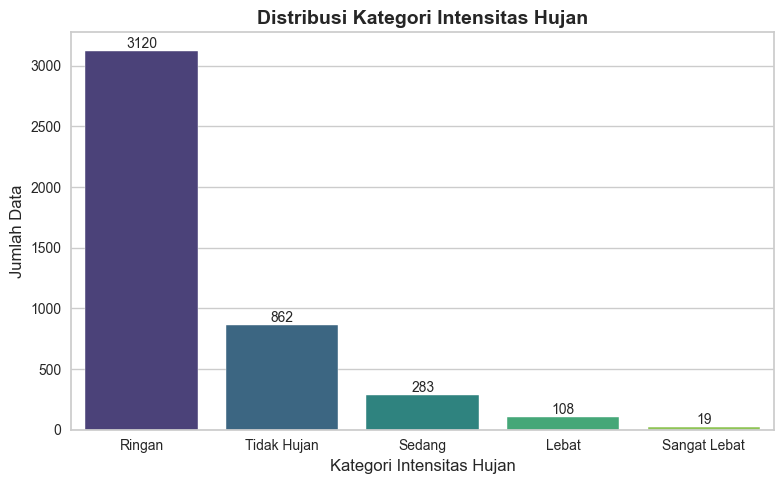

In [61]:
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")

sns.countplot(
    data=data,
    x='intensitas_hujan',
    order=data['intensitas_hujan'].value_counts().index,
    palette="viridis"
)

plt.title("Distribusi Kategori Intensitas Hujan", fontsize=14, fontweight='bold')
plt.xlabel("Kategori Intensitas Hujan", fontsize=12)
plt.ylabel("Jumlah Data", fontsize=12)

for p in plt.gca().patches:
    plt.gca().annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

VISUALISASI PETA FORECASTING INTENSITAS HUJAN 7 HARI KE DEPAN DI STASIUN BMKG SELURUH JAWA TIMUR TAHUN 2024 MENGGUNAKAN PYCARET

In [62]:
data['tanggal'] = pd.to_datetime(data['tanggal'], errors='coerce').dt.date
tanggal_unik = sorted(data['tanggal'].dropna().unique())

display(HTML("""
<style>
.jp-Widget[df-widget="DatePicker"] input, 
.jp-Widget[df-widget="Dropdown"] select {
    width: fit-content !important;
    min-width: 150px;
    padding: 3px 8px;
}
</style>
"""))

COLOR_MAP = {
    "Tidak Hujan": "green",
    "Ringan": "blue",
    "Sedang": "orange",
    "Lebat": "red",
    "Sangat Lebat": "maroon"
}

date_picker = widgets.DatePicker(
    description='Pilih Tanggal:',
    disabled=False,
    value=tanggal_unik[0] if tanggal_unik else None,
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='fit-content', min_width='150px')
)

data_option = widgets.Dropdown(
    options=['Aktual'] + [f'Forecast H+{i}' for i in range(1, 8)],
    description='Pilih Jenis Data:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='fit-content', min_width='180px')
)

output = widgets.Output()

def tampilkan_peta(change=None):
    with output:
        clear_output(wait=True)
        tanggal_input = date_picker.value

        if not tanggal_input:
            print("Silakan pilih tanggal terlebih dahulu.")
            return
        if tanggal_input not in tanggal_unik:
            print(f"Data untuk tanggal {tanggal_input.strftime('%Y/%m/%d')} tidak ditemukan.")
            return

        data_filter = data[data['tanggal'] == tanggal_input]
        if data_filter.empty:
            print(f"Tidak ada data untuk tanggal {tanggal_input.strftime('%Y/%m/%d')}.")
            return

        kolom_map = {'Aktual': ('intensitas_hujan', 'Aktual')}
        for i in range(1, 8):
            kolom_map[f'Forecast H+{i}'] = (f'intensitas_forecast_{i}', f'Forecast H+{i}')

        kolom, judul = kolom_map[data_option.value]

        lat_center = data_filter['latitude'].mean()
        lon_center = data_filter['longitude'].mean()
        lat_range = data_filter['latitude'].max() - data_filter['latitude'].min()
        lon_range = data_filter['longitude'].max() - data_filter['longitude'].min()
        zoom_level = 7 if max(lat_range, lon_range) > 0.4 else 8 if max(lat_range, lon_range) > 0.2 else 10

        fig = px.scatter_mapbox(
            data_filter,
            lat="latitude",
            lon="longitude",
            color=kolom,
            color_discrete_map=COLOR_MAP,
            hover_name="stasiun",
            hover_data={col: True for col in data_filter.columns},
            zoom=zoom_level,
            height=600,
            title=f"Peta {judul} Intensitas Curah Hujan - Stasiun BMKG seluruh Jawa Timur ({tanggal_input})"
        )

        fig.update_layout(
            mapbox_style="open-street-map",
            mapbox_center={"lat": lat_center, "lon": lon_center},
            showlegend=False,
            margin={"r": 0, "t": 50, "l": 0, "b": 0},
            title=dict(font=dict(size=18, color='black', family="Arial"), x=0.5)
        )

        fig.update_traces(marker=dict(size=18, opacity=0.9))
        fig.show()

        legend_html = """
        <div style="font-family: Arial; font-size: 14px; margin-top: 10px;">
            <b>Legenda Intensitas Hujan:</b><br>
            <span style='color:green;'>● Tidak Hujan</span> &nbsp;
            <span style='color:blue;'>● Ringan</span> &nbsp;
            <span style='color:orange;'>● Sedang</span> &nbsp;
            <span style='color:red;'>● Lebat</span> &nbsp;
            <span style='color:maroon;'>● Sangat Lebat</span>
        </div>
        """
        display(HTML(legend_html))

        html_table = data_filter.to_html(index=False, justify='center', border=1, classes='table table-striped')
        scrollable_table = f"""
        <div style="overflow-x: auto; border: 1px solid #ddd; border-radius: 5px; padding: 5px; margin-top: 5px;">
            {html_table}
        </div>
        """
        display(HTML("<h4 style='font-family: Arial;'>Data pada tanggal terpilih:</h4>"))
        display(HTML(scrollable_table))

date_picker.observe(tampilkan_peta, names='value')
data_option.observe(tampilkan_peta, names='value')

display(widgets.HBox([date_picker, data_option]))
display(output)

Output()